In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from env import TransitNetworkEnv
from logger import TrainingEpisodeLogger
from agent import Model, collect_rollout, ppo_update, fixed_policy
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import json

In [2]:
env = TransitNetworkEnv({"is_training": True, "seed": 0})
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

def get_model(device, load_weights=False, pth="model.pth"):
    model = Model(
        env.observation_spaces["agent_0"],
        env.action_spaces["agent_0"],
        gnn_hidden_dim=128,
        gnn_num_heads=4,
        embed_size=128,
        transformer_num_heads=4,
        num_encoder_layers=4,
        num_decoder_layers=8,
        dropout_rate=0.1,
    )
    
    model = model.to(device)
    if os.path.isfile(pth) and load_weights:
        model.load_state_dict(torch.load(pth, map_location=torch.device('cpu')))
    return model

model = get_model(device, load_weights=True)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
print("parameters:", sum([p.numel() for p in model.parameters()])/1e6, "M")

parameters: 2.395652 M


In [ ]:
from tqdm import tqdm
from agent import to_torch, to_device
from matplotlib import pyplot as plt

total_deployed_buses_by_policy = 0
total_deployed_buses_by_random = 0
reports = []
all_rewards = []
window = 1
for seed in [
             828920903,
             115601515,
             989005593,
             267626564, 
             913751312, 
             398943963, 
             436715962, 
             624311666, 
             433623492]:
    
    fig = plt.figure(figsize=(20,10))
    (ax_1, ax_2) = fig.subplots(1, 2)
    to_print = ""
    all_log = []


    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})    
    obs, _ = env.reset()
    env.transit_system.topology.show(ax=ax_1)
    model = get_model(device, load_weights=True).eval()

    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
    (
        obs_buf,
        action_buf,
        reward_buf,
        terminated_buf,
        truncated_buf,
        info_buf,
        logp_buf,
        value_buf,
    ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
    reports.append(env.transit_system.report)

    actions = {}
    rewards = {}
    for agent_id in env.possible_agents:
        for i in range(len(reward_buf[agent_id])):
            if i not in actions:
                actions[i] = []
            actions[i].append(action_buf[agent_id][i])

            if i not in rewards:
                rewards[i] = []
            rewards[i].append(reward_buf[agent_id][i])

    policy_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
    all_rewards.append(policy_rewards)
    total_deployed_buses_by_policy = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
    to_print += f"deployed_buses_gnn={total_deployed_buses_by_policy.item():.3f}, mean_rewards={np.mean(policy_rewards):.4f}"

    
    # env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
    ## obs, _ = env.reset()
    # model = "random"
    # (
    #     obs_buf,
    #     action_buf,
    #     reward_buf,
    #     terminated_buf,
    #     truncated_buf,
    #     info_buf,
    #     logp_buf,
    #     value_buf,
    # ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
    # reports.append(env.transit_system.report)

    # actions = {}
    # rewards = {}
    # for agent_id in env.possible_agents:
    #     for i in range(len(reward_buf[agent_id])):
    #         if i not in actions:
    #             actions[i] = []
    #         actions[i].append(action_buf[agent_id][i])

    #         if i not in rewards:
    #             rewards[i] = []
    #         rewards[i].append(reward_buf[agent_id][i])

    
    # agnostic_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
    # all_rewards.append(agnostic_rewards)
    # total_deployed_buses_by_random = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
    # to_print += f"\ndeployed_buses_rnd={total_deployed_buses_by_random.item():.3f}, mean_rewards={np.mean(agnostic_rewards):.4f}"


    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
    # obs, _ = env.reset()
    with open(f"SA_TT/{seed}.pkl", "rb") as file:
        sa_tt = pkl.load(file)
    model = {"policy": sa_tt}

    (
        obs_buf,
        action_buf,
        reward_buf,
        terminated_buf,
        truncated_buf,
        info_buf,
        logp_buf,
        value_buf,
    ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
    reports.append(env.transit_system.report)

    actions = {}
    rewards = {}
    for agent_id in env.possible_agents:
        for i in range(len(reward_buf[agent_id])):
            if i not in actions:
                actions[i] = []
            actions[i].append(action_buf[agent_id][i])

            if i not in rewards:
                rewards[i] = []
            rewards[i].append(reward_buf[agent_id][i])

    
    sa_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
    all_rewards.append(sa_rewards)
    total_deployed_buses_by_sa = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
    to_print += f"\ndeployed_buses_sa={total_deployed_buses_by_sa.item():.3f}, mean_rewards={np.mean(sa_rewards):.4f}"



    for minute in [5, 15, 30]:
        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
        # obs, _ = env.reset()
        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, fixed_policy(minute*60), rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)
    
        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])
    
                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])
                
        
        fp_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
        all_rewards.append(fp_rewards)
        total_deployed_buses_by_fp = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
        ax_2.plot(np.cumsum(fp_rewards), label=f"FP{minute}")
        to_print += f"\ntotal_deployed_buses_by_fp{minute}={total_deployed_buses_by_fp:.3f}, mean_reward={np.mean(fp_rewards):.4f}"
    
    ax_2.plot(np.cumsum(policy_rewards), label="GNN")
    # ax_2.plot(np.cumsum(agnostic_rewards), label="Random")
    ax_2.plot(np.cumsum(sa_rewards), label="SA")
    
    ax_2.legend()
    plt.show()
    
    print(to_print)
    print()

In [3]:
# import pickle as pkl
# with open("variables.pkl", "wb") as file:
#     pkl.dump((all_rewards, reports), file)

import pickle as pkl
with open("variables.pkl", "rb") as file:
    (all_rewards, reports) = pkl.load(file)

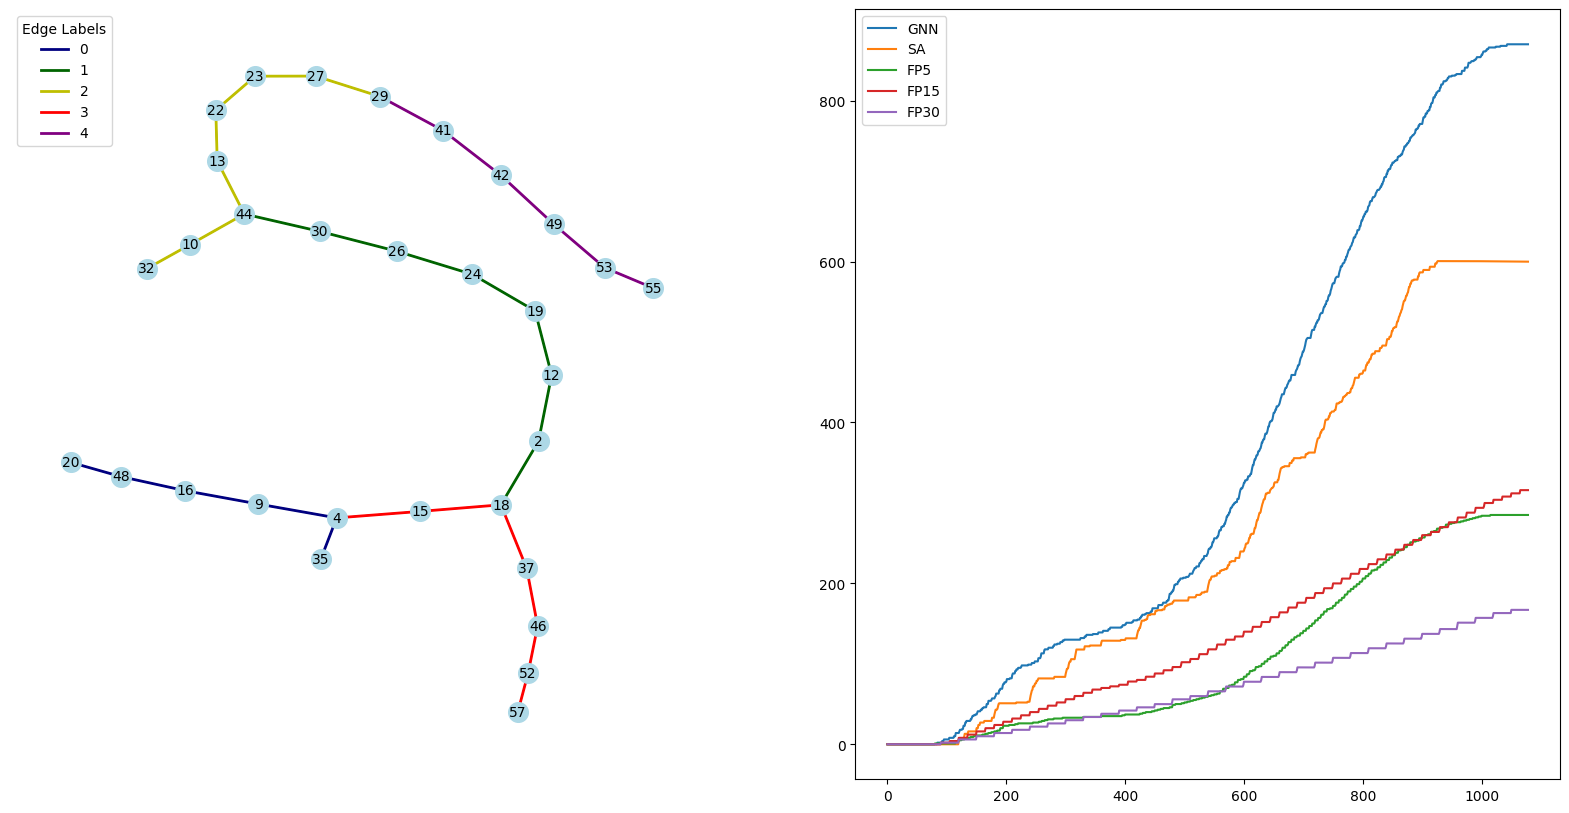

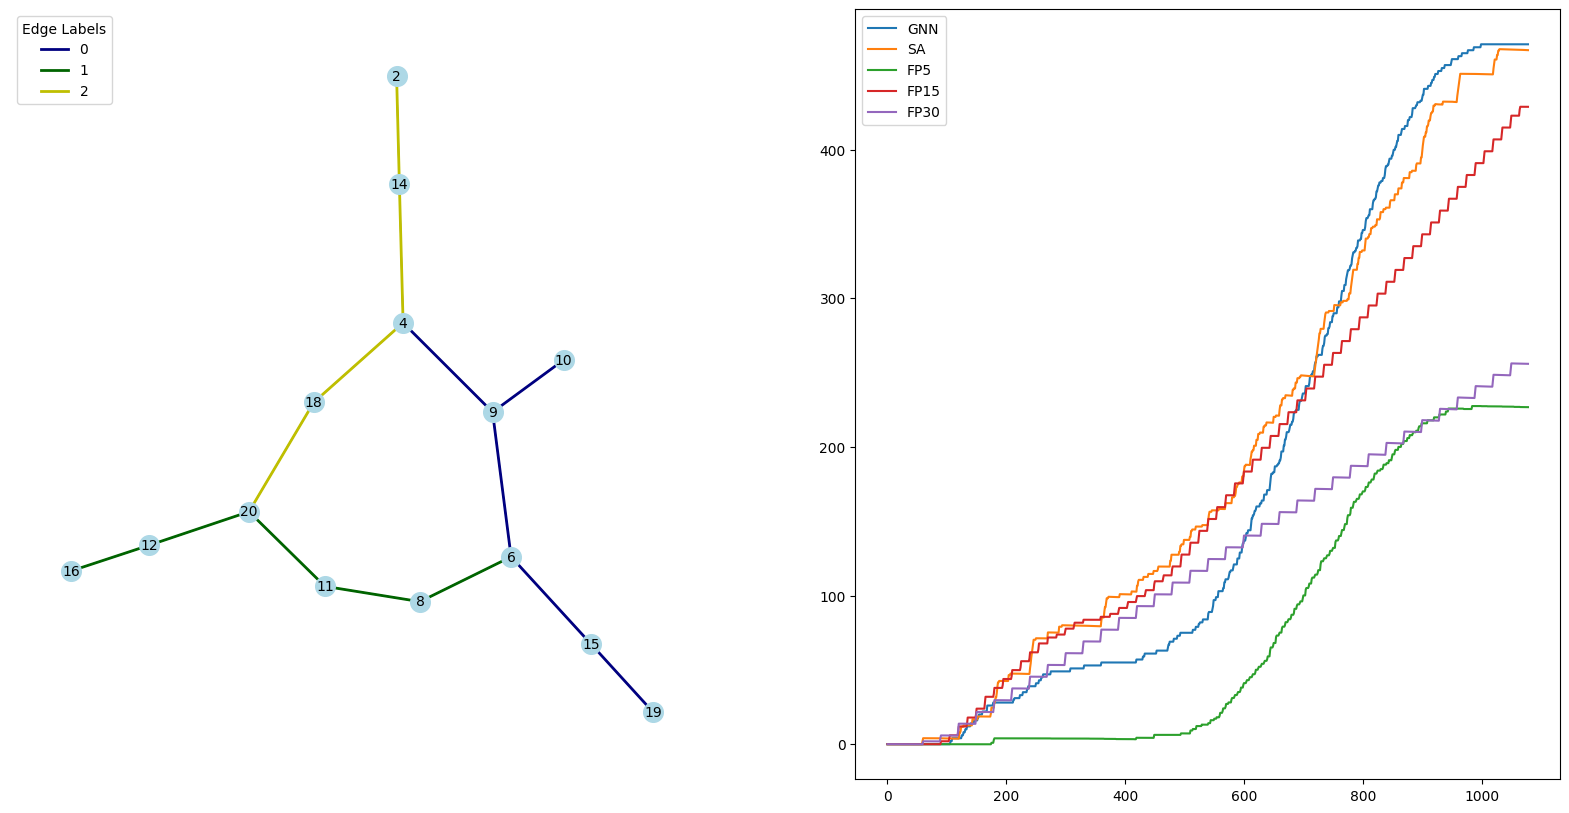

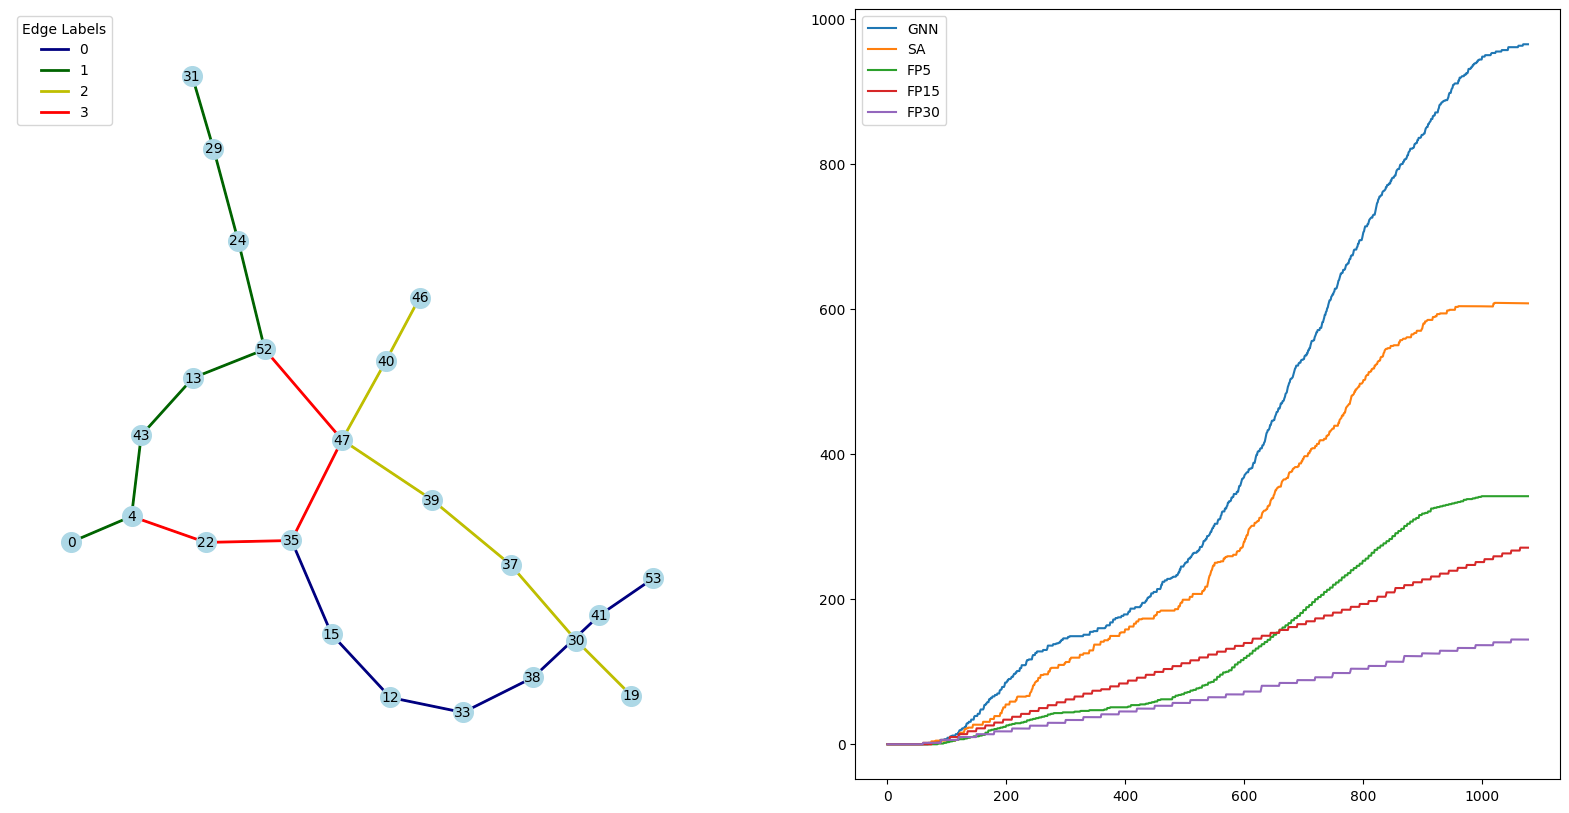

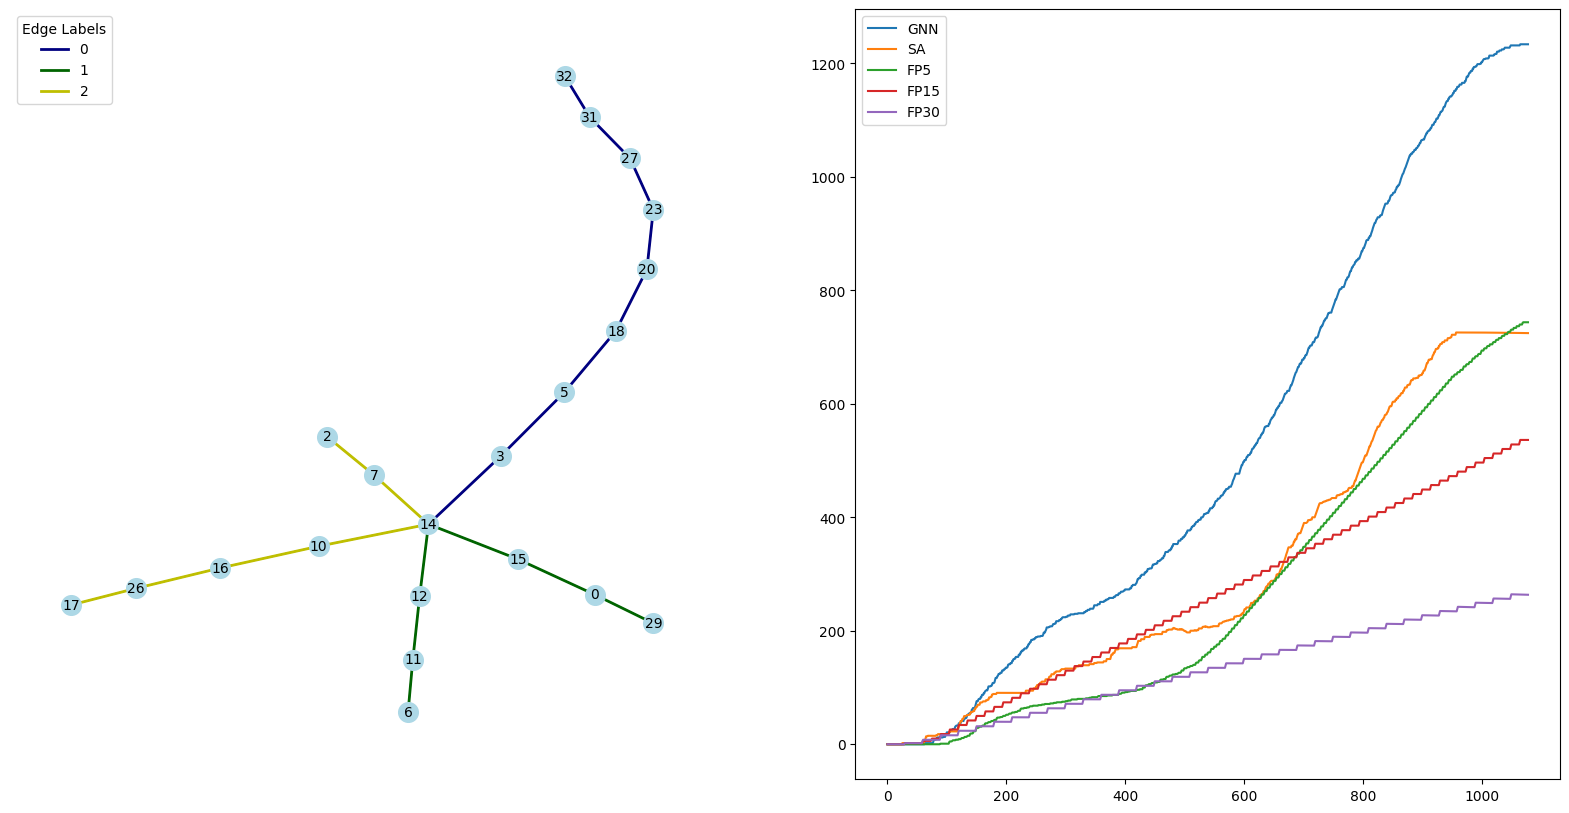

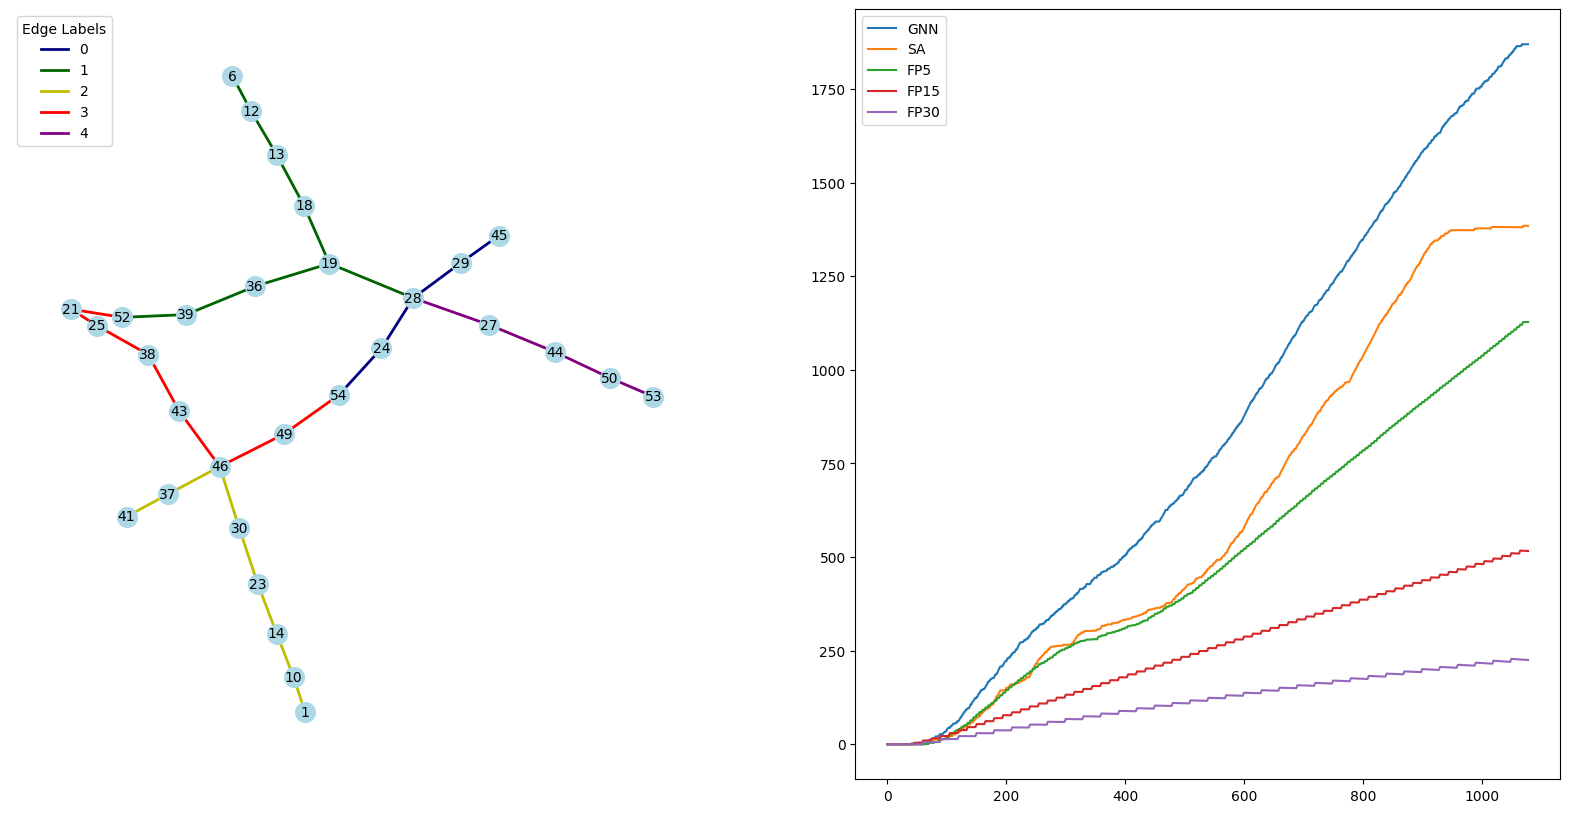

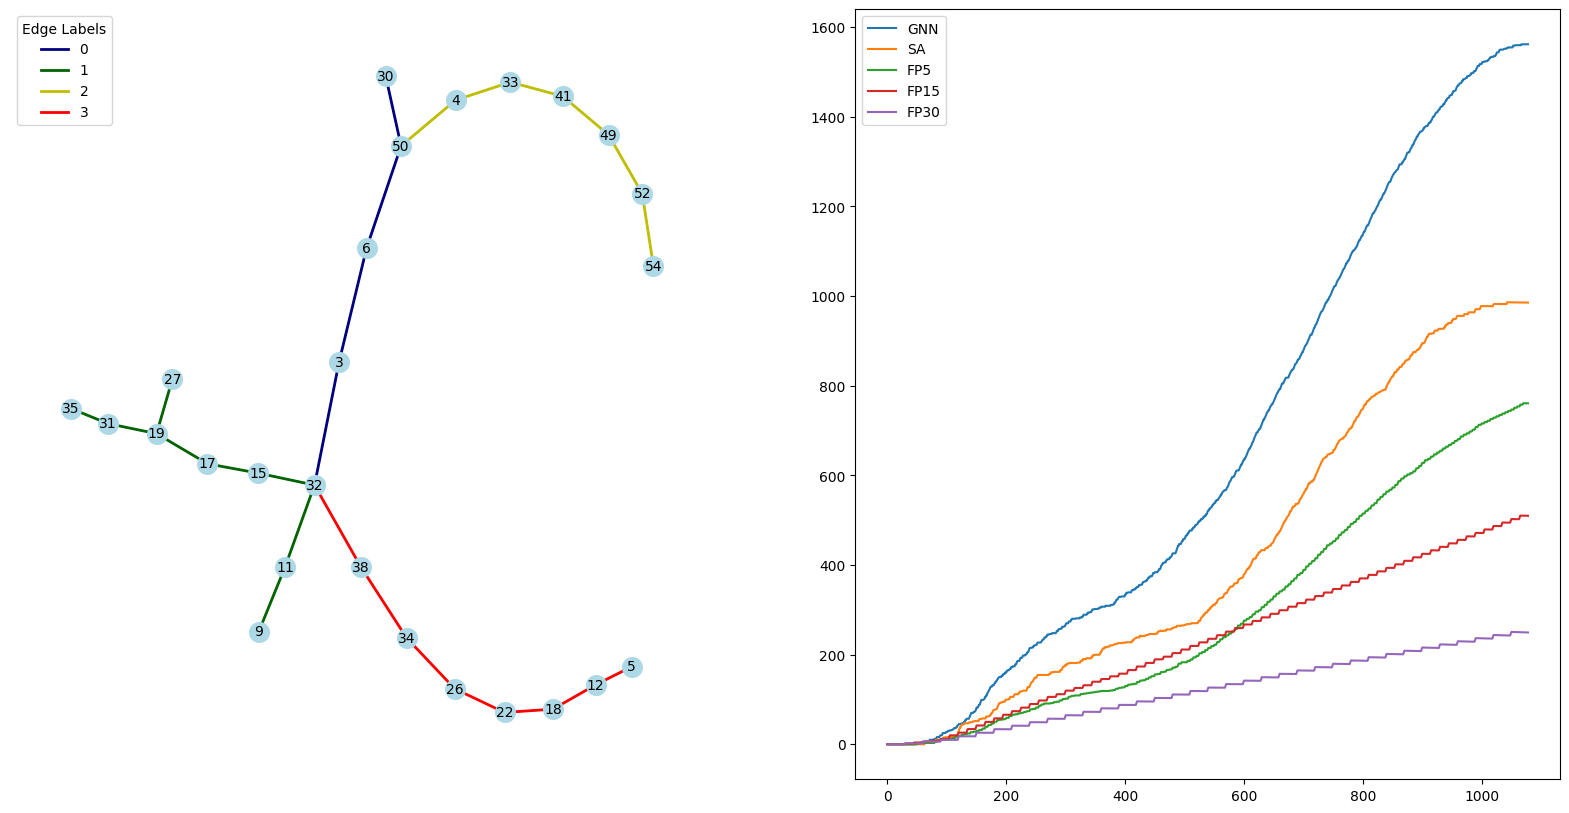

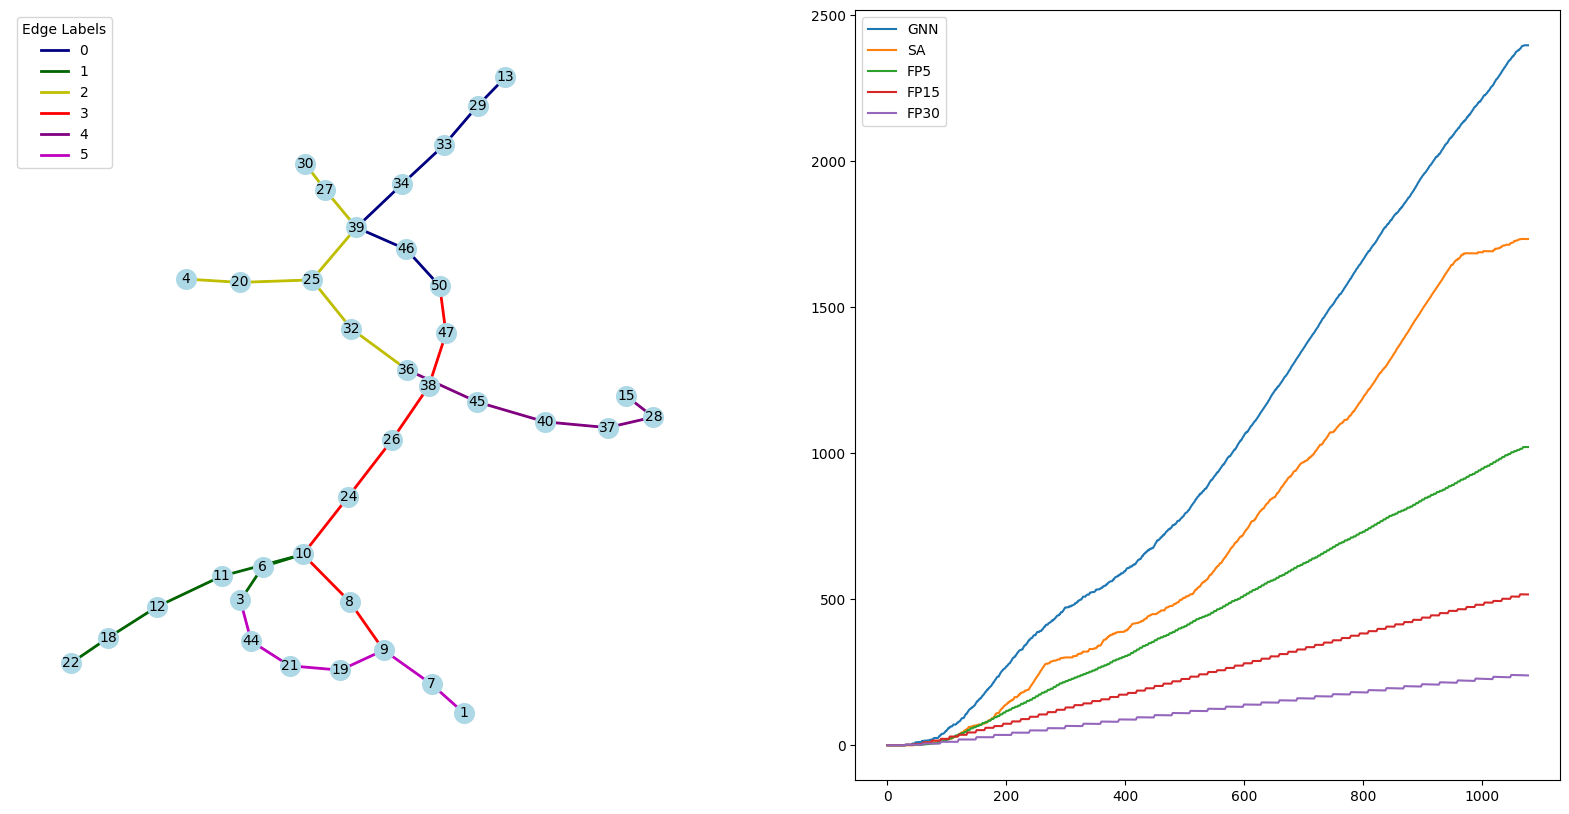

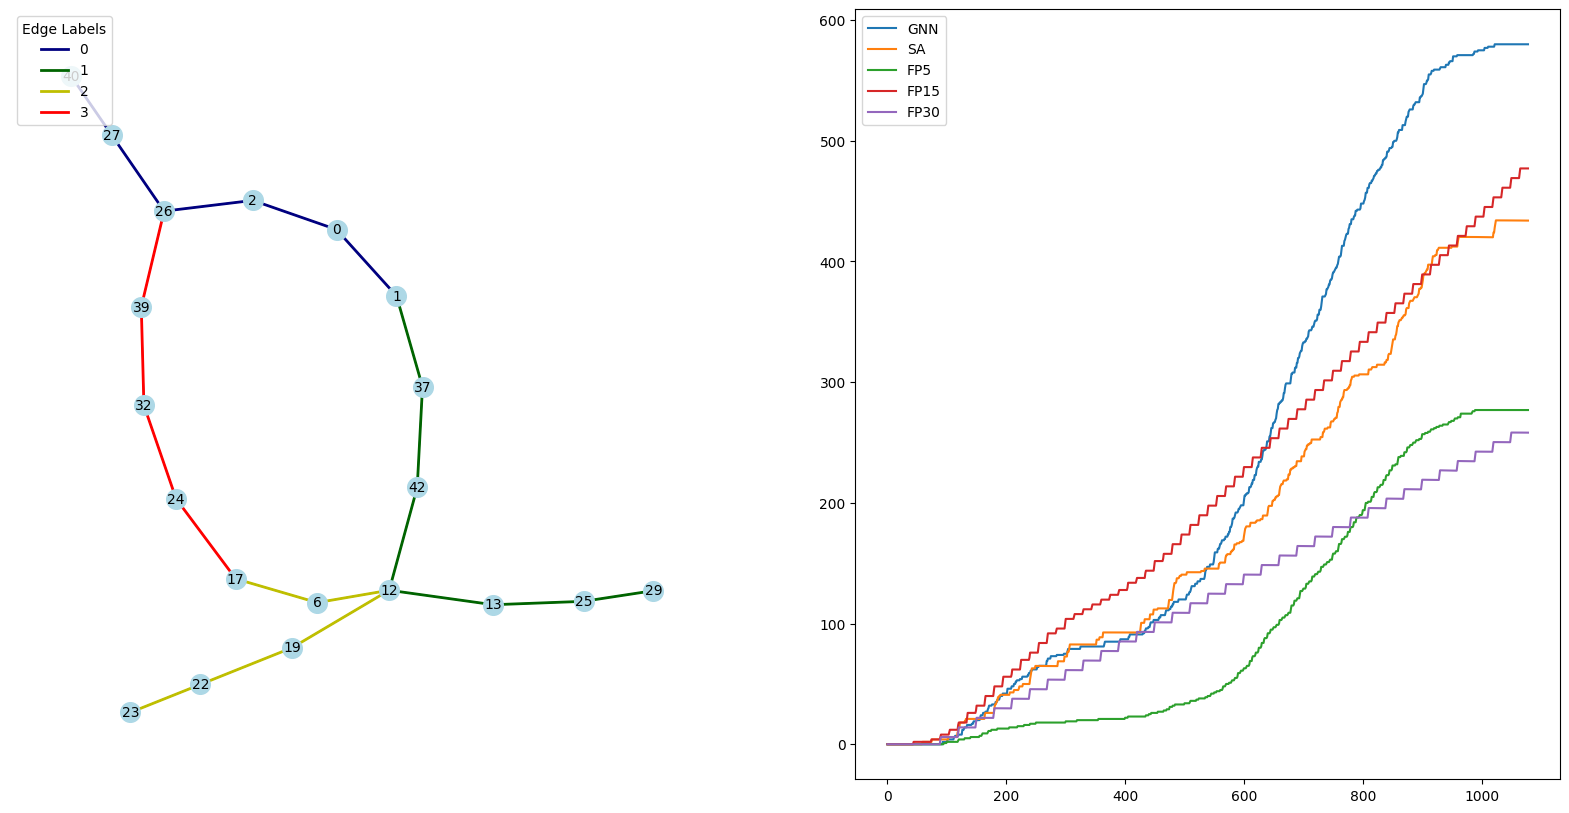

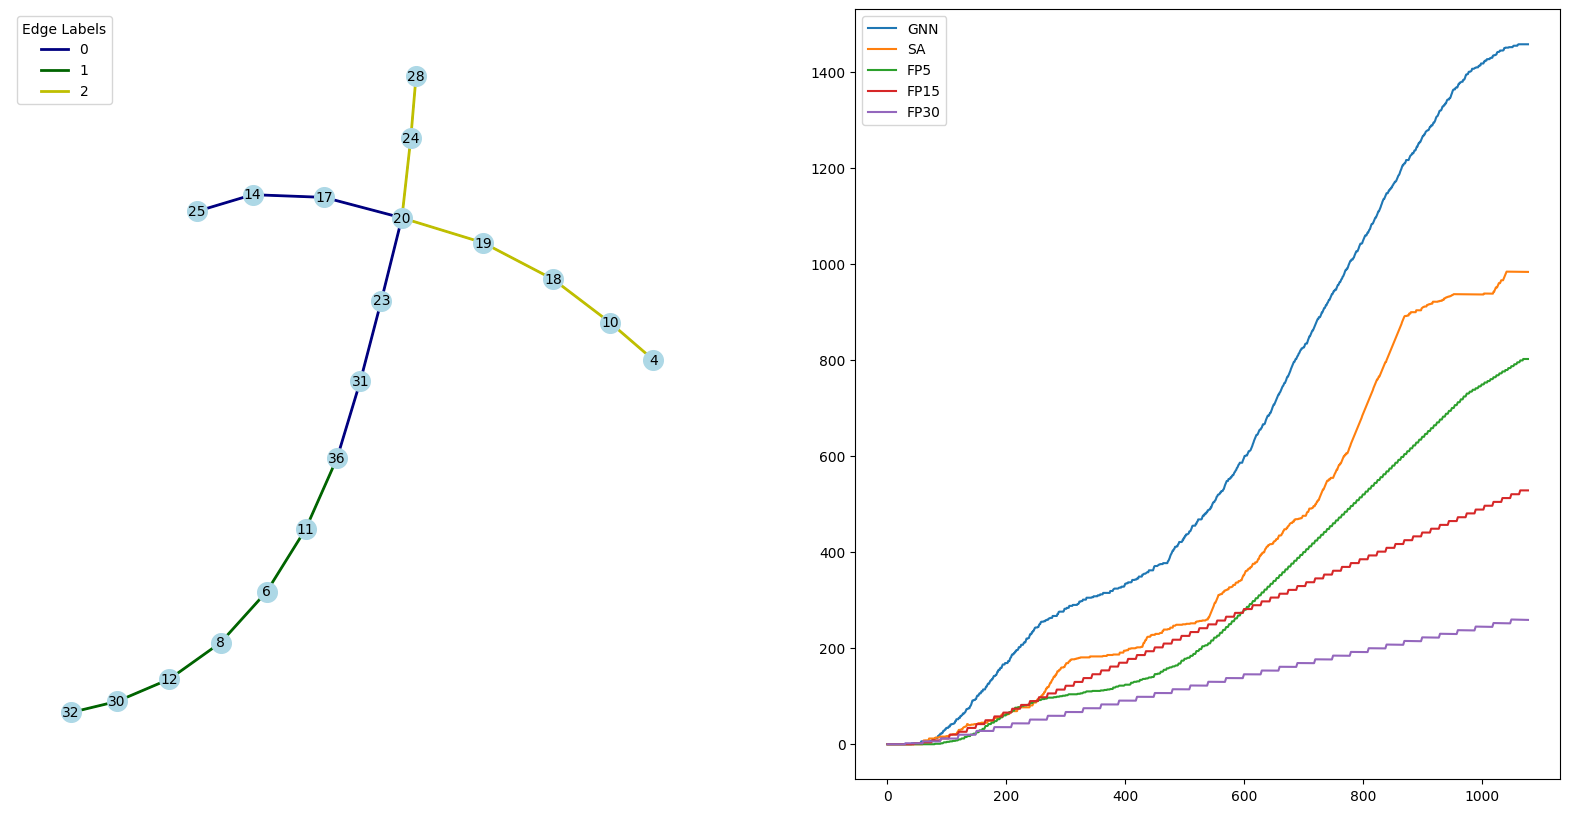

In [32]:
from tqdm import tqdm
from agent import to_torch, to_device
from matplotlib import pyplot as plt

i = 0
for seed in [
             828920903,
             115601515,
             989005593,
             267626564, 
             913751312, 
             398943963, 
             436715962, 
             624311666, 
             433623492]:
    
    fig = plt.figure(figsize=(20,10))
    (ax_1, ax_2) = fig.subplots(1, 2)
    to_print = ""
    all_log = []


    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})    
    obs, _ = env.reset()
    env.transit_system.topology.show(ax=ax_1)

    policy_rewards = all_rewards[i]; i+=1
    sa_rewards =all_rewards[i]; i+=1

    ax_2.plot(np.cumsum(policy_rewards), label="GNN")
    ax_2.plot(np.cumsum(sa_rewards), label="SA")
    for minute in [5, 15, 30]:
        fp_rewards = all_rewards[i]; i+=1
        ax_2.plot(np.cumsum(fp_rewards), label=f"FP{minute}")
    ax_2.legend()
    plt.show()
    
    print(to_print)
    print()

Text(0, 0.5, 'Hourly rewards')

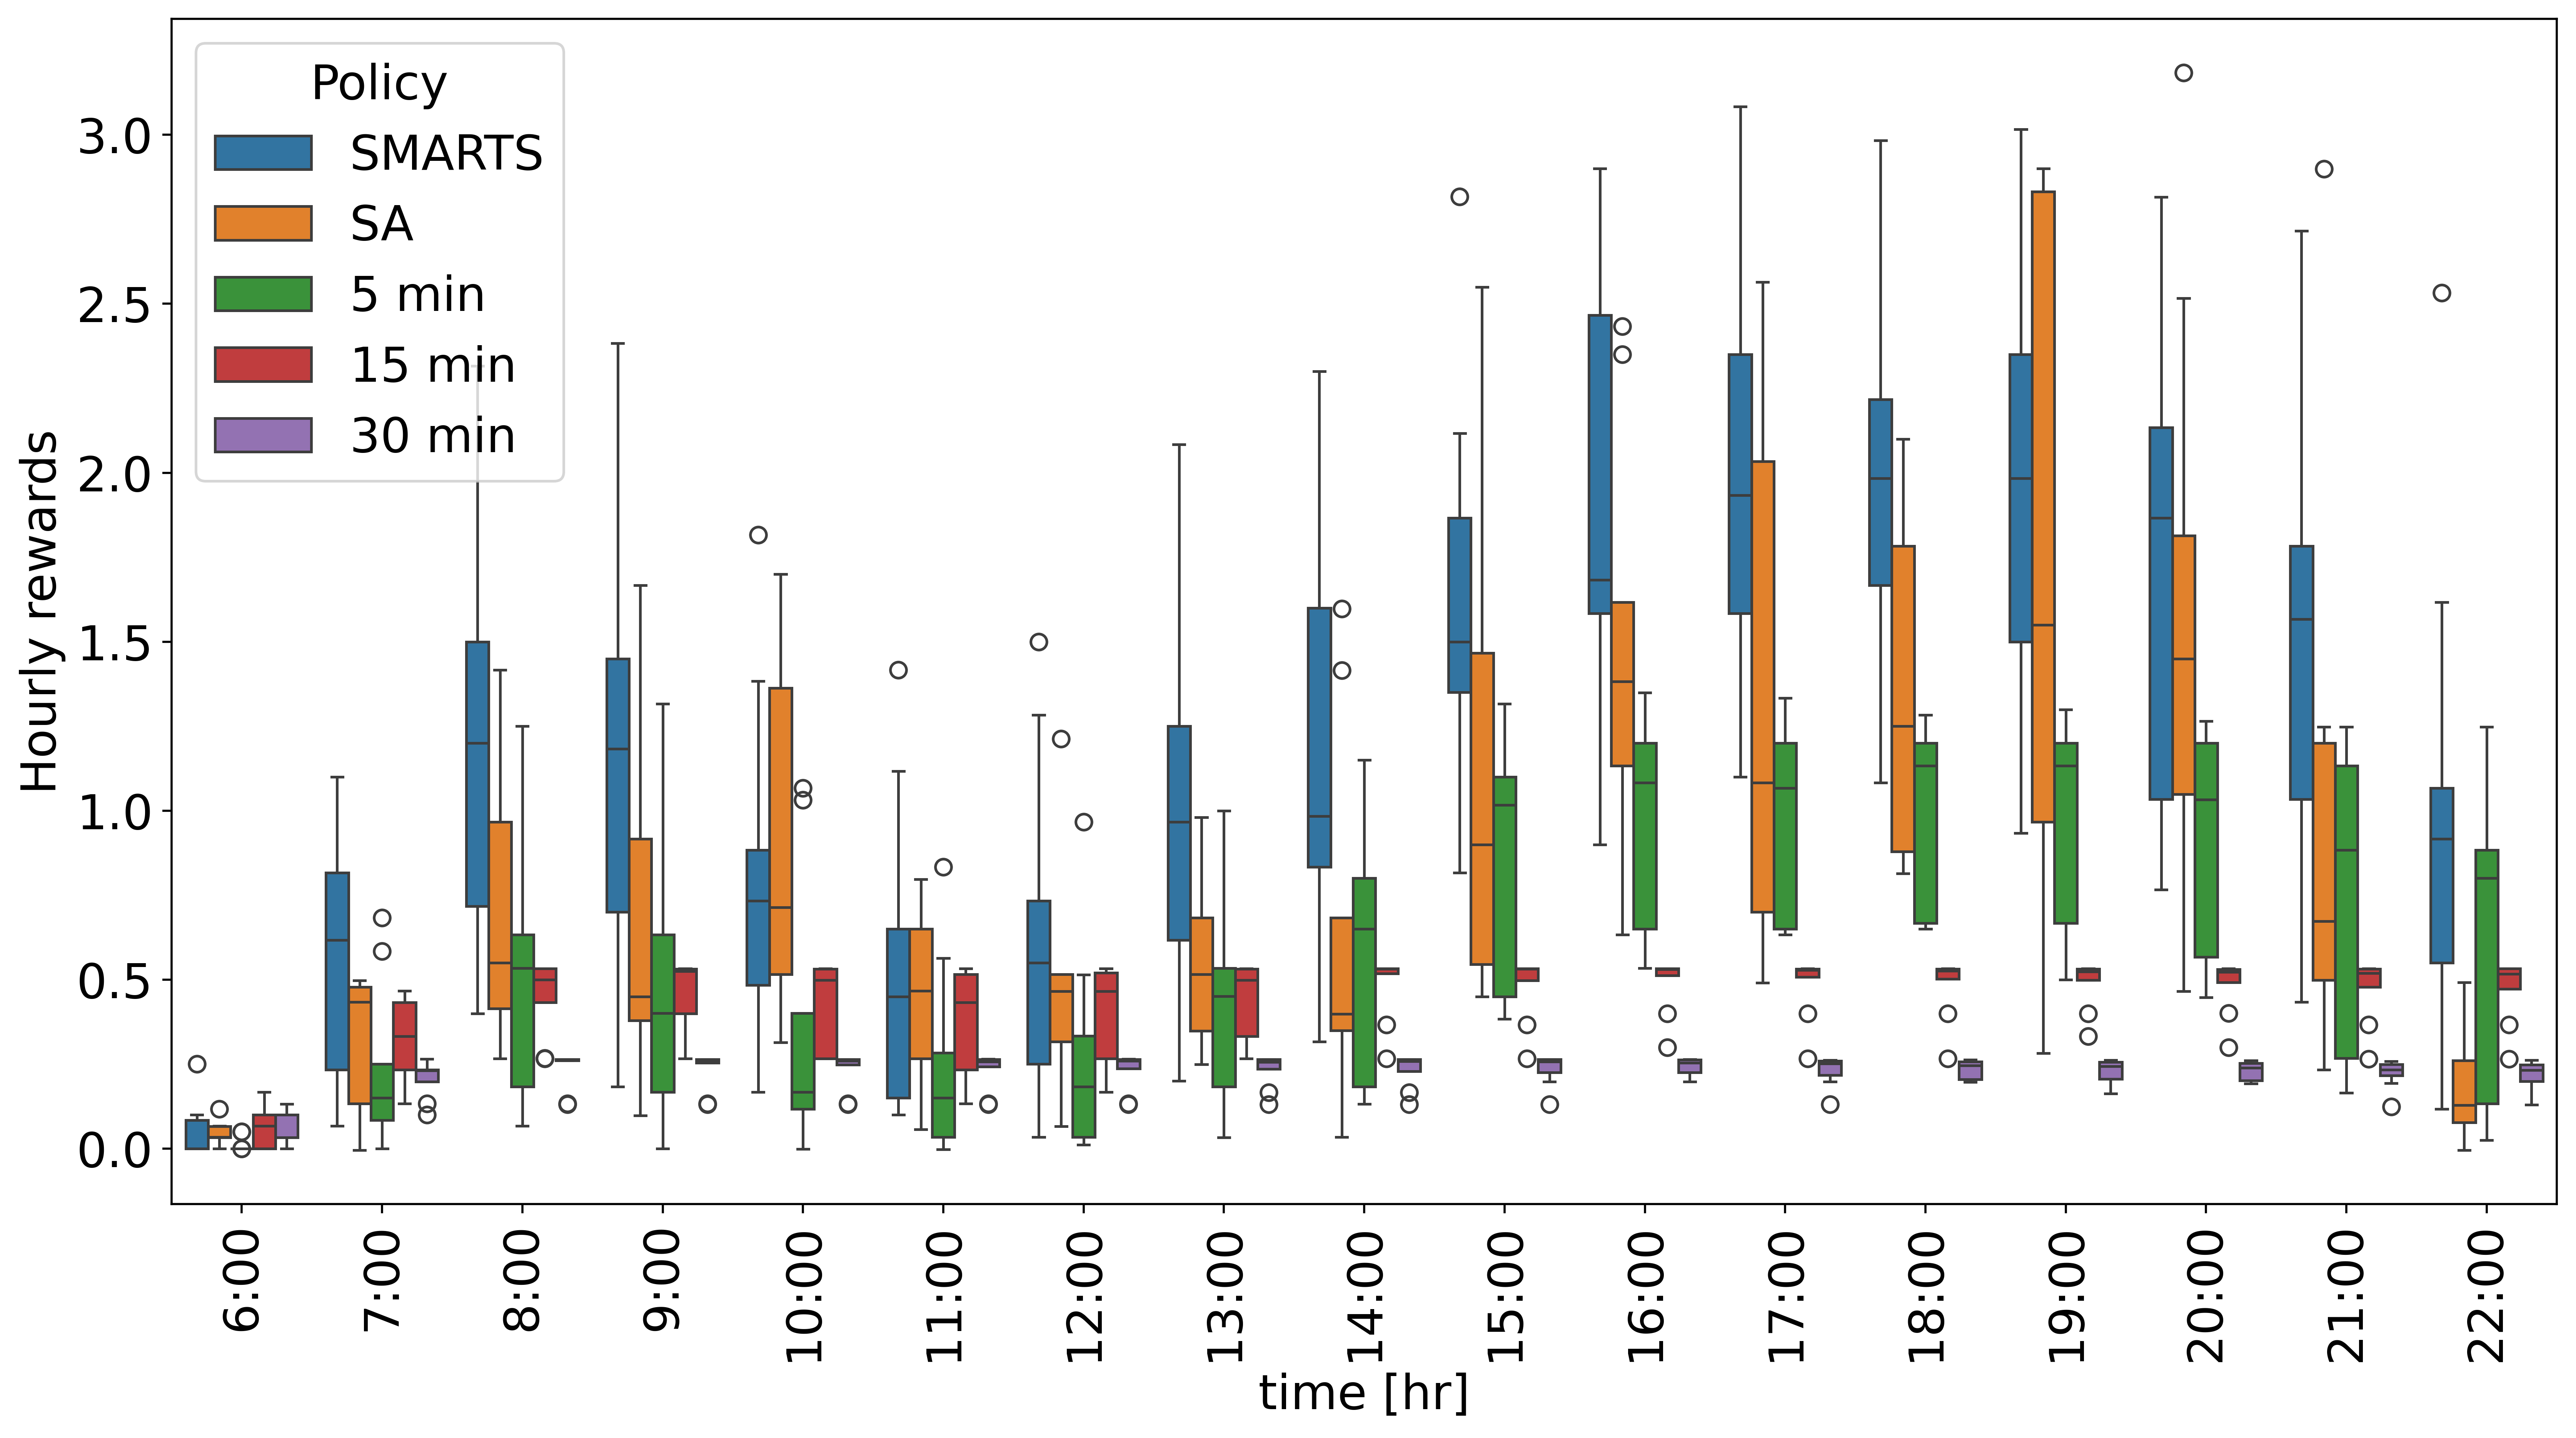

In [4]:
# names = ["GNN", "Uniform PD", "SA", "5 min", "15 min", "30 min"]
names = ["SMARTS", "SA", "5 min", "15 min", "30 min"]

window = 60
n = len(names)
N = 9
res = pd.concat([pd.concat([pd.DataFrame(r).T.rolling(window=window, step=window).mean().dropna().iloc[:, i] for i in range(N)]).to_frame().rename(columns={0: name})
               for r, name in zip([[all_rewards[i] for i in range(j,n*N,n)] for j in range(n)], names) ], axis=1).reset_index()
res = pd.melt(res, id_vars=["index"], value_vars=names).rename(columns={"value": "reward", "variable": "Policy", "index": "time"})


plt.figure(figsize=(16,8), dpi=500)
plt.rc('font', size=18)
mask = res.Policy != "Uniform PD"
sns.boxplot(data=res.loc[mask], x="time", y="reward", hue="Policy")
time_labels = np.array(sorted(res.time.unique().tolist()))
plt.xticks(ticks=range(0,len(time_labels)), labels=[f"{int(i/60)+5}:{int(i/60 - int(i/60)):02d}" for i in time_labels], rotation=90)

plt.xlabel("time [hr]")
plt.ylabel("Hourly rewards")

Text(0, 0.5, 'cumulative rewards')

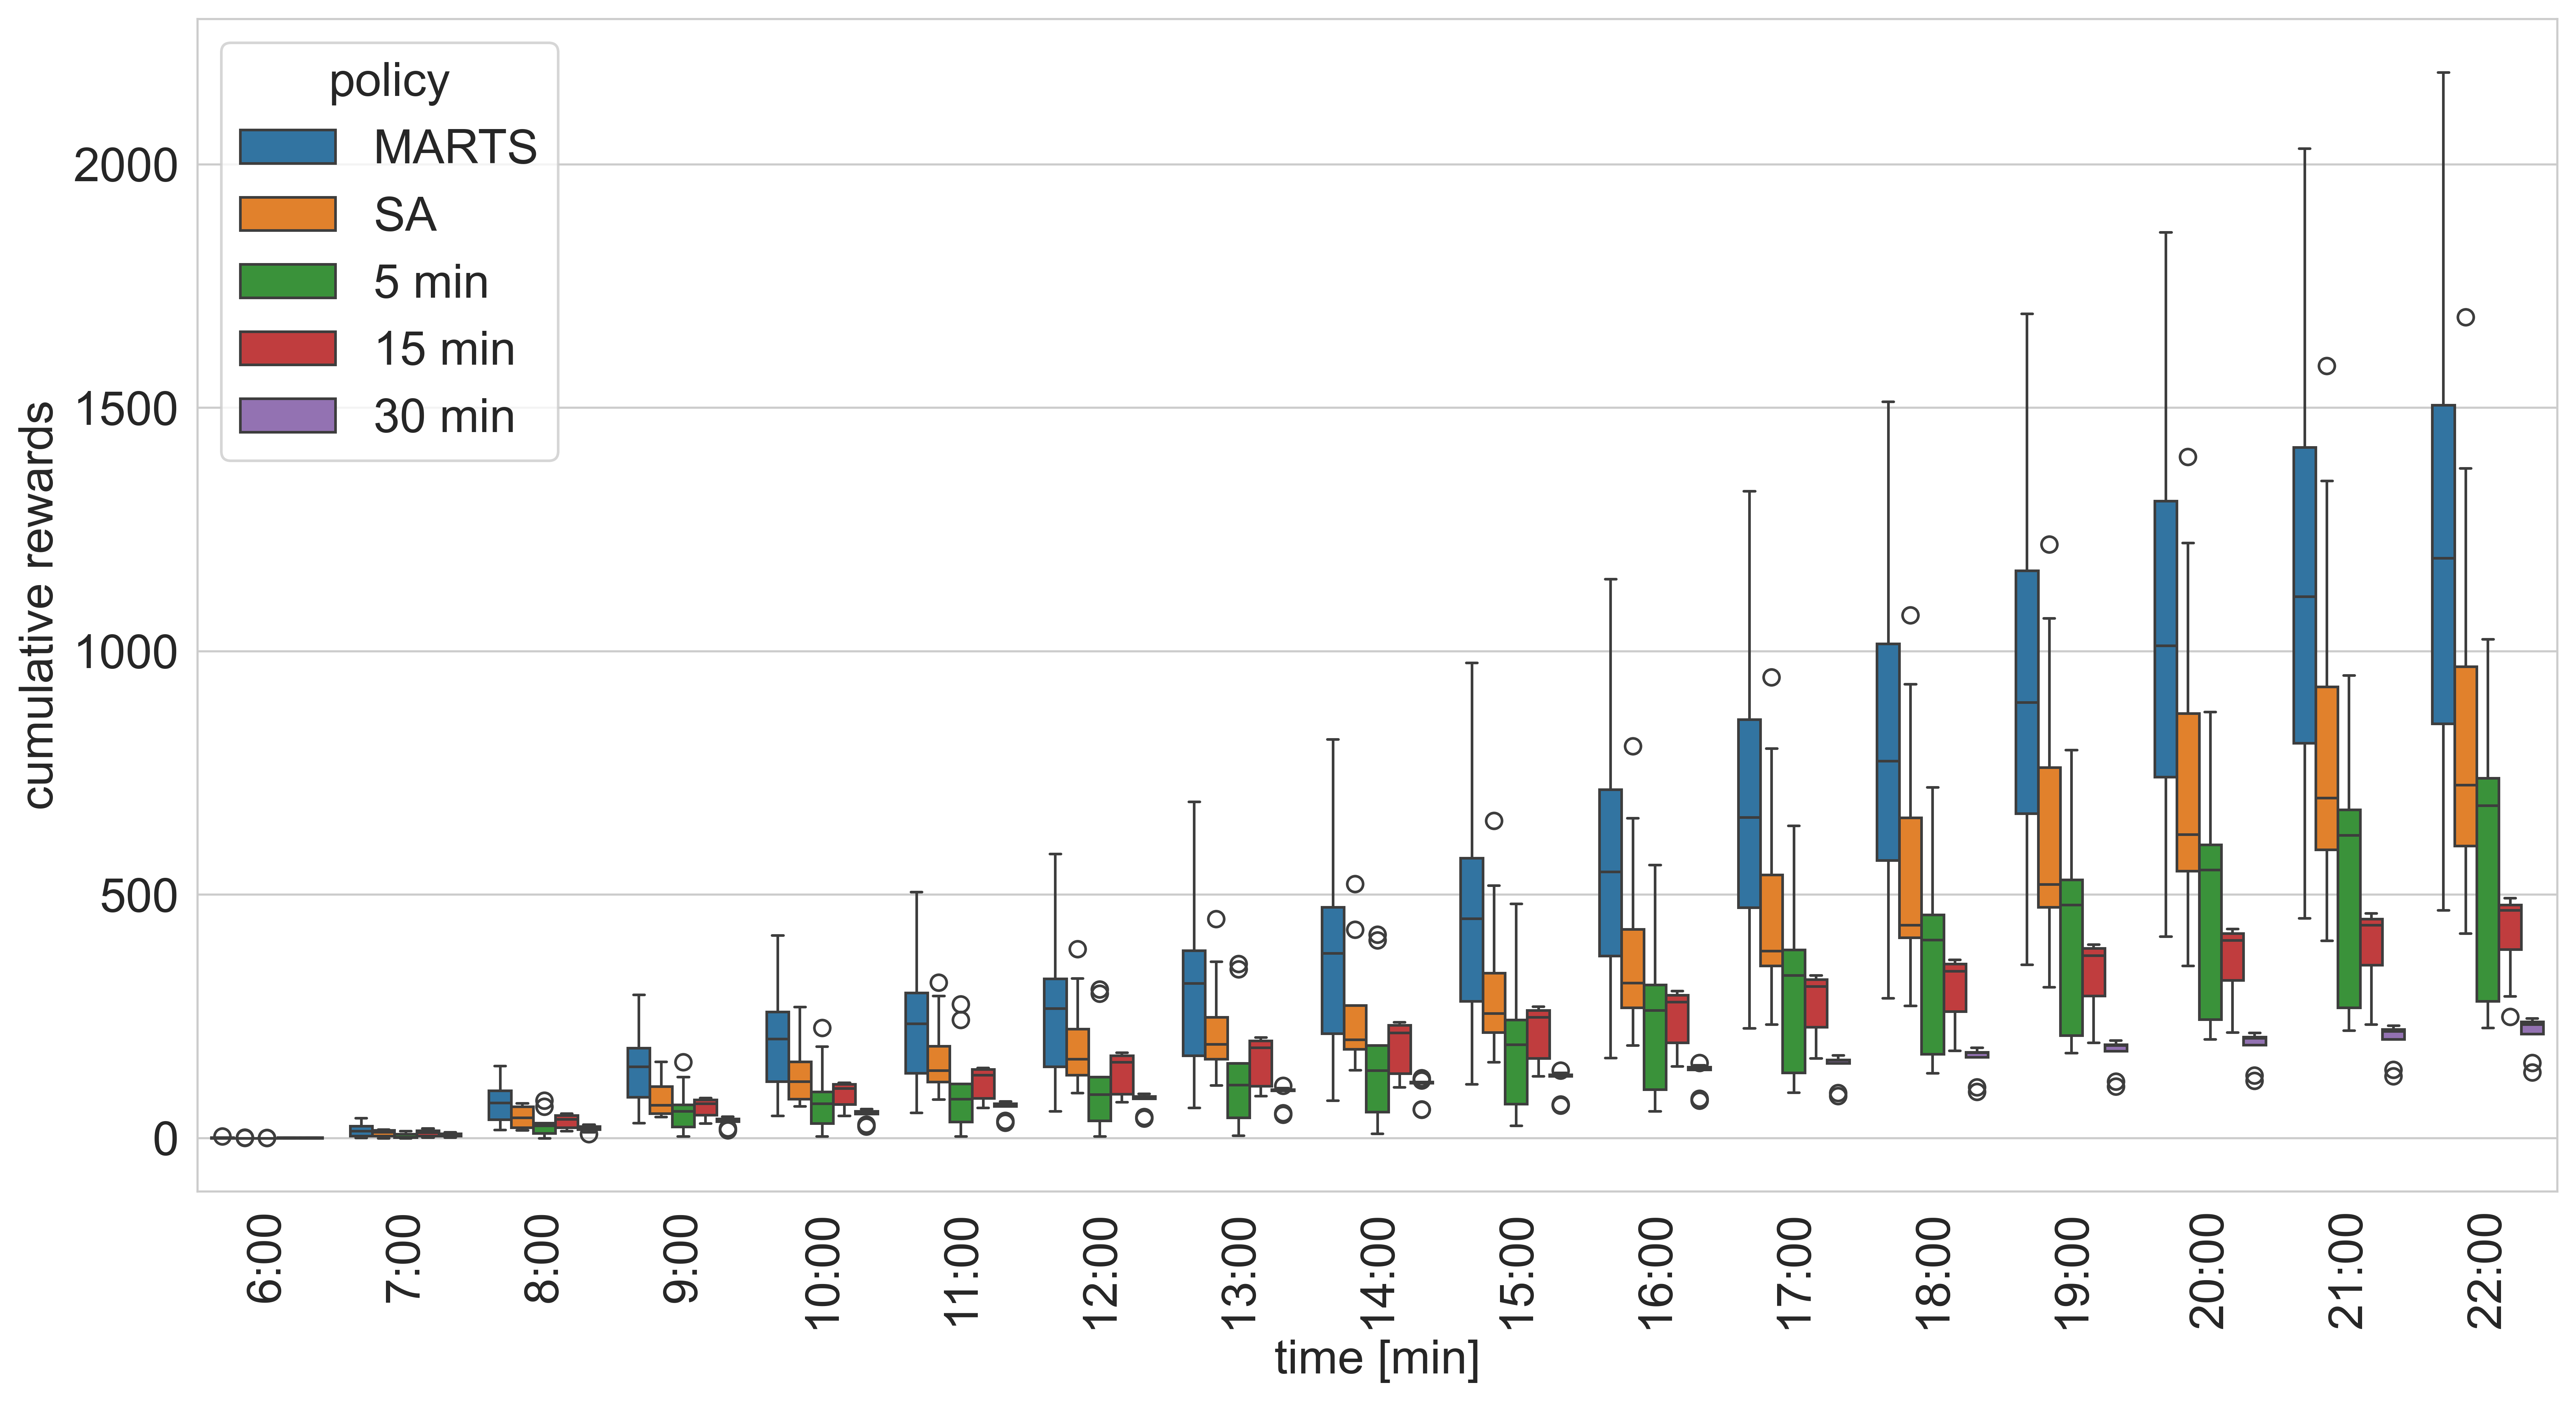

In [24]:
# names = ["GNN", "Uniform PD", "SA", "5 min", "15 min", "30 min"]
names = ["MARTS", "SA", "5 min", "15 min", "30 min"]

window = 60
n = len(names)
N = 9
res = pd.concat([pd.concat([pd.DataFrame(r).T.cumsum().rolling(window=window, step=window).mean().dropna().iloc[:, i] for i in range(N)]).to_frame().rename(columns={0: name})
               for r, name in zip([[all_rewards[i] for i in range(j,n*N,n)] for j in range(n)], names) ], axis=1).reset_index()
res = pd.melt(res, id_vars=["index"], value_vars=names).rename(columns={"value": "reward", "variable": "policy", "index": "time"})


plt.figure(figsize=(16,8), dpi=500)
plt.rc('font', size=18) 
mask = res.policy != "Uniform PD"
sns.boxplot(data=res.loc[mask], x="time", y="reward", hue="policy")
time_labels = np.array(sorted(res.time.unique().tolist()))
plt.xticks(ticks=range(0,len(time_labels)), labels=[f"{int(i/60)+5}:{int(i/60 - int(i/60)):02d}" for i in time_labels], rotation=90)

plt.xlabel("time [min]")
plt.ylabel("cumulative rewards")

In [5]:
def p75(x):
    p = np.percentile(x, q=75)
    return p

names = ["SMARTS", "SA", "5 min", "15 min", "30 min"]
n = len(names)
N = 9
ii = 0
jj = n
fff = []
for _ in range(N):
    num_routes = len([k for k in reports[0][0] if "served_passengers" in k]) - 1
    ff = (pd.concat([pd.DataFrame(reports[i]).T[['total_deployed_buses', 
                                           'total_done_buses', 
                                           'total_avg_waiting_time', 
                                           'total_avg_average_stranded_count',
                                           'served_passengers',
                                           'vehicle_occupancy_rate']]
                    .assign(vehicle_occupancy_rate=lambda x: x.vehicle_occupancy_rate.map(lambda x: None if len(x)==0 else np.mean(x)))
                    .agg({'total_done_buses':"sum", 
                          'total_avg_waiting_time':"median", 
                          'total_avg_average_stranded_count':"median", 
                          'served_passengers':"sum",
                          'vehicle_occupancy_rate': "max"})
                    .dropna() for i in range(ii,jj)], axis=1)
                    .rename(columns={i:n for i,n in enumerate(names)}).T
                    .assign(done_buses_per_route= lambda x: x.total_done_buses/num_routes))
    
    fff.append(ff)
    ii = jj
    jj += n
fff = pd.concat(fff).reset_index().rename(columns={"index": "policy"})

c:\Users\muk0003\OneDrive - Auburn University\Desktop\GNN-Transit-Scheduler\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\muk0003\OneDrive - Auburn University\Desktop\GNN-Transit-Scheduler\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\muk0003\OneDrive - Auburn University\Desktop\GNN-Transit-Scheduler\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\muk0003\OneDrive - Auburn University\Desktop\GNN-Transit-Scheduler\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\muk0003\OneDrive - Auburn University\Desktop\GNN-Transit-Scheduler\

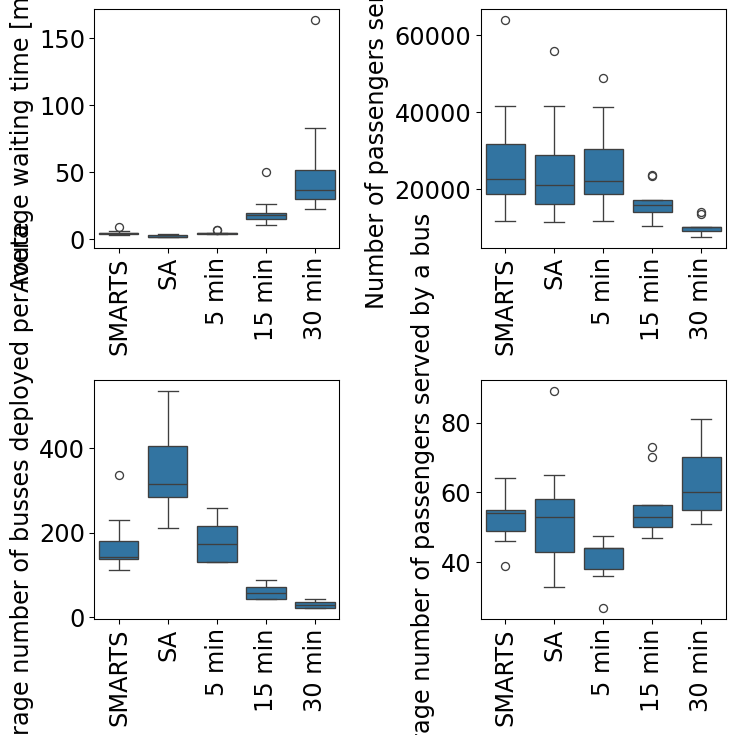

In [6]:
dpi = 96
figsize = (8,8)
# fig = plt.figure(figsize=figsize, dpi=dpi)
fig = plt.figure(figsize=figsize, dpi=dpi)
plt.subplot(2,2,1)
sns.boxplot(data=fff[["policy", "total_avg_waiting_time"]], x="policy", y="total_avg_waiting_time")
plt.xticks(rotation=90)
plt.xlabel(None)
plt.ylabel("Average waiting time [min]")
plt.grid(False)
# plt.show()

plt.subplot(2,2,2)
# fig = plt.figure(figsize=figsize, dpi=dpi)

sns.boxplot(data=fff[["policy", "served_passengers"]], x="policy", y="served_passengers")
plt.xticks(rotation=90)
plt.xlabel(None)
plt.ylabel("Number of passengers served")
plt.grid(False)

# plt.show()


plt.subplot(2,2,3)
# fig = plt.figure(figsize=figsize, dpi=dpi)

sns.boxplot(data=fff[["policy", "done_buses_per_route"]], x="policy", y="done_buses_per_route")
plt.xticks(rotation=90)
plt.xlabel(None)
plt.ylabel("Average number of busses deployed per route")
fig.tight_layout()
plt.grid(False)

# plt.show()


plt.subplot(2,2,4)
# fig = plt.figure(figsize=figsize, dpi=dpi)

sns.boxplot(data=fff[["policy", "vehicle_occupancy_rate"]], x="policy", y="vehicle_occupancy_rate")
plt.xticks(rotation=90)
plt.xlabel(None)
plt.ylabel("Average number of passengers served by a bus")
plt.grid(False)

plt.show()

fig.tight_layout()

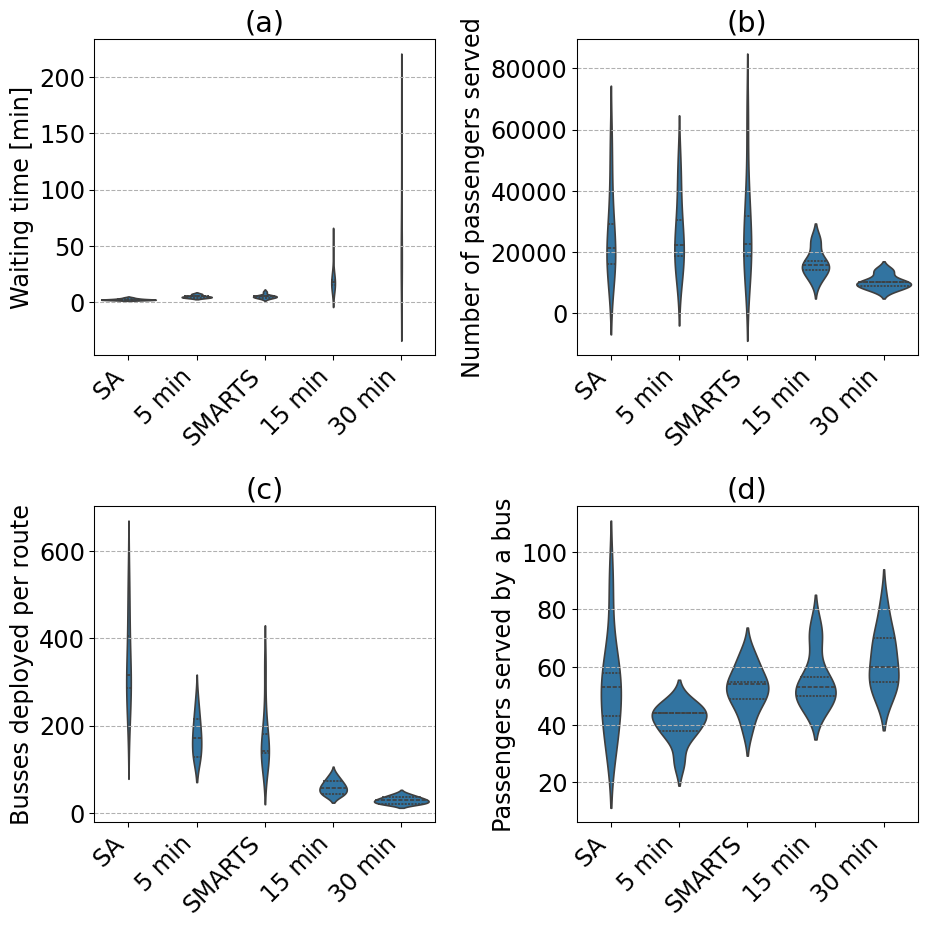

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume 'fff' DataFrame is available with data from multiple runs ---

dpi = 96
figsize = (10, 10) # Adjusted for better visual spacing

# --- Calculate plot order based on median waiting time for all four charts ---
# This helps compare policies consistently across all metrics.
# Note: This line requires the actual 'fff' DataFrame to execute successfully.
# If 'fff' is large, calculating the order here is efficient.
try:
    order = fff.groupby('policy')['total_avg_waiting_time'].median().sort_values().index
except KeyError:
    # Fallback to default if 'fff' structure isn't fully defined/available
    order = None 

fig = plt.figure(figsize=figsize, dpi=dpi)

## Subplot 1: Average waiting time
plt.subplot(2, 2, 1)
# Use violinplot with inner="quartile" to show density AND median/quartiles
sns.violinplot(data=fff[["policy", "total_avg_waiting_time"]], 
               x="policy", 
               y="total_avg_waiting_time", 
               order=order, 
               inner="quartile") 
plt.xticks(rotation=45, ha='right') # Rotate less and align better
plt.xlabel(None)
plt.ylabel("Waiting time [min]")
plt.title("(a)")
plt.grid(axis='y', linestyle='--')

## Subplot 2: Served passengers
plt.subplot(2, 2, 2)
sns.violinplot(data=fff[["policy", "served_passengers"]], 
               x="policy", 
               y="served_passengers", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Number of passengers served")
plt.title("(b)")
plt.grid(axis='y', linestyle='--')

## Subplot 3: Done buses per route
plt.subplot(2, 2, 3)
sns.violinplot(data=fff[["policy", "done_buses_per_route"]], 
               x="policy", 
               y="done_buses_per_route", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Busses deployed per route")
plt.title("(c)")
plt.grid(axis='y', linestyle='--')

## Subplot 4: Vehicle occupancy rate
plt.subplot(2, 2, 4)
sns.violinplot(data=fff[["policy", "vehicle_occupancy_rate"]], 
               x="policy", 
               y="vehicle_occupancy_rate", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Passengers served by a bus")
plt.title("(d)")
plt.grid(axis='y', linestyle='--')

fig.tight_layout()
plt.show() # Display the final figure

In [ ]:
from tqdm import tqdm
from agent import to_torch, to_device
from matplotlib import pyplot as plt

saved_cfg = {}
with open("transit_system_config.json", "r") as file:
    cfg = json.load(file)
saved_cfg.update(cfg)

total_deployed_buses_by_policy = 0
total_deployed_buses_by_random = 0
reports = []
all_rewards = []
num_users = []
window = 1

for mean_pop in range(500, 25000, 2500):
    for seed in [828920903]:
        with open("transit_system_config.json", "r") as file:
            cfg = json.load(file)

        cfg["mean_population_density"] = mean_pop
        cfg["mean_catchment_radius"] = 1
        cfg["std_catchment_radius"] = 0.0001
        
        cfg["min_transit_users_proportion"] = 0.050
        cfg["max_transit_users_proportion"] = 0.051
        
        with open("transit_system_config.json", "w") as file:
            json.dump(cfg, file)


        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
        _, _, = env.reset()
        pops = [n.transit_users for n in env.transit_system.topology.nodes]
        # print("min={:0.0f}, mean={:0.0f}, max={:0.0f}".format(np.min(pops), np.mean(pops), np.max(pops)))

        to_print = ""
        all_log = []

        model = get_model(device, load_weights=True).eval()
        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)
        num_users.append(sum([n.passenger_counter for n in env.transit_system.topology.nodes]))

        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        policy_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
        all_rewards.append(policy_rewards)
        total_deployed_buses_by_policy = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
        to_print += f"deployed_buses_gnn={total_deployed_buses_by_policy.item():.3f}, mean_rewards={np.mean(policy_rewards):.4f}"

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
        with open(f"SA_TT/{seed}.pkl", "rb") as file:
            sa_tt = pkl.load(file)
        model = {"policy": sa_tt}

        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)

        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        
        sa_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
        all_rewards.append(sa_rewards)
        total_deployed_buses_by_sa = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
        to_print += f"\ndeployed_buses_sa={total_deployed_buses_by_sa.item():.3f}, mean_rewards={np.mean(sa_rewards):.4f}"

        for minute in [5, 15, 30]:
            env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
            (
                obs_buf,
                action_buf,
                reward_buf,
                terminated_buf,
                truncated_buf,
                info_buf,
                logp_buf,
                value_buf,
            ) = collect_rollout(env, fixed_policy(minute*60), rollout_len=100_000, device=device, hard_reset=True, testing=True)
            reports.append(env.transit_system.report)
        
            actions = {}
            rewards = {}
            for agent_id in env.possible_agents:
                for i in range(len(reward_buf[agent_id])):
                    if i not in actions:
                        actions[i] = []
                    actions[i].append(action_buf[agent_id][i])
        
                    if i not in rewards:
                        rewards[i] = []
                    rewards[i].append(reward_buf[agent_id][i])
                    
            
            fp_rewards = pd.Series(sum([i for i in rewards.values()], [])).rolling(window=len(env.possible_agents)*window, step=len(env.possible_agents)*window).max().dropna().to_list()
            all_rewards.append(fp_rewards)
            total_deployed_buses_by_fp = sum([sum(i) for i in actions.values()])/float(len(env.possible_agents))
            to_print += f"\ntotal_deployed_buses_by_fp{minute}={total_deployed_buses_by_fp:.3f}, mean_reward={np.mean(fp_rewards):.4f}"
        
        print(to_print)
        print("number of daily transit users = ", num_users[-1])
        print()

with open("transit_system_config.json", "w") as file:
    json.dump(saved_cfg, file)

deployed_buses_gnn=87.000, mean_rewards=0.1881
deployed_buses_sa=315.300, mean_rewards=0.1268
total_deployed_buses_by_fp5=216.000, mean_reward=0.0343
total_deployed_buses_by_fp15=72.000, mean_reward=0.1353
total_deployed_buses_by_fp30=36.000, mean_reward=0.1185
number of daily transit users =  2604

deployed_buses_gnn=152.800, mean_rewards=0.7118
deployed_buses_sa=318.400, mean_rewards=0.5734
total_deployed_buses_by_fp5=216.000, mean_reward=0.2122
total_deployed_buses_by_fp15=72.000, mean_reward=0.2816
total_deployed_buses_by_fp30=36.000, mean_reward=0.1598
number of daily transit users =  7138

deployed_buses_gnn=225.400, mean_rewards=1.4235
deployed_buses_sa=319.800, mean_rewards=1.0929
total_deployed_buses_by_fp5=216.000, mean_reward=0.5060
total_deployed_buses_by_fp15=72.000, mean_reward=0.3756
total_deployed_buses_by_fp30=36.000, mean_reward=0.2071
number of daily transit users =  14772

deployed_buses_gnn=264.100, mean_rewards=2.0028
deployed_buses_sa=325.100, mean_rewards=1.4923

In [1]:
# with open("variables_2.pkl", "wb") as file:
#     pkl.dump((all_rewards, reports, num_users), file)

with open("variables_2.pkl", "rb") as file:
    (all_rewards, reports, num_users) = pkl.load(file)

num_users = list(map(lambda x: x* 1.5, num_users))

NameError: name 'pkl' is not defined

Text(0, 0.5, 'Total users served [thousands]')

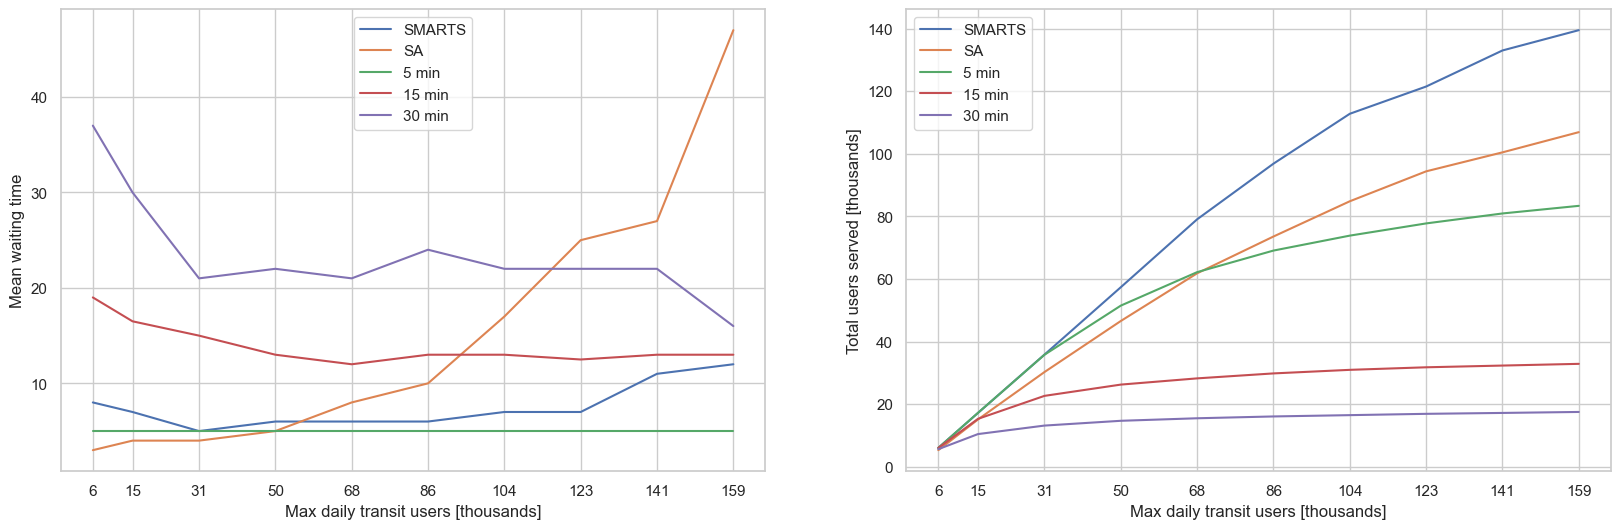

In [16]:
vars = ["served_passengers", ]
names = ["SMARTS", "SA", "5 min", "15 min", "30 min"]

data = {}
i = 0

for nu in num_users:
    rpt = reports[i:i+len(names)]
    i += len(names)
    for j, name in enumerate(names):
        f = pd.DataFrame(rpt[j]).T.total_avg_waiting_time.dropna().median()
        # f = pd.DataFrame(rpt[j]).T.total_avg_waiting_time.dropna().values
        # f = np.quantile(f, q=.99)
        if int(nu) not in data:
            data[int(nu)] = {}
        data[int(nu)][name] = f

fig = plt.figure(figsize=(20,6))

ax = plt.subplot(1,2,1)
pd.DataFrame(data).T.plot(ax=ax)
ticks = pd.DataFrame(data).T.index
plt.xticks(ticks=ticks, labels=(pd.DataFrame(data).T.index/1000).astype(int).to_list())
plt.xlabel("Max daily transit users [thousands]")
plt.ylabel("Mean waiting time")


# data = {}
# i = 0
# for nu in num_users:
#     rpt = reports[i:i+len(names)]
#     i += len(names)
#     for j, name in enumerate(names):
#         f = pd.DataFrame(rpt[j]).T.total_deployed_buses.dropna().sum()
#         if int(nu) not in data:
#             data[int(nu)] = {}
#         data[int(nu)][name] = f

# ax = plt.subplot(2,2,2)
# pd.DataFrame(data).T.plot(ax=ax)
# plt.xticks(ticks=ticks, labels=(pd.DataFrame(data).T.index/1000).astype(int).to_list())
# plt.xlabel("Max daily transit users [thousands]")
# plt.ylabel("Total deployed vehicles")


data = {}
i = 0
for nu in num_users:
    rpt = reports[i:i+len(names)]
    i += len(names)
    for j, name in enumerate(names):
        f = pd.DataFrame(rpt[j]).T.served_passengers.dropna().sum()
        if int(nu) not in data:
            data[int(nu)] = {}
        data[int(nu)][name] = f/1000

ax = plt.subplot(1,2,2)
pd.DataFrame(data).T.plot(ax=ax)
plt.xticks(ticks=ticks, labels=(pd.DataFrame(data).T.index/1000).astype(int).to_list())
plt.xlabel("Max daily transit users [thousands]")
plt.ylabel("Total users served [thousands]")


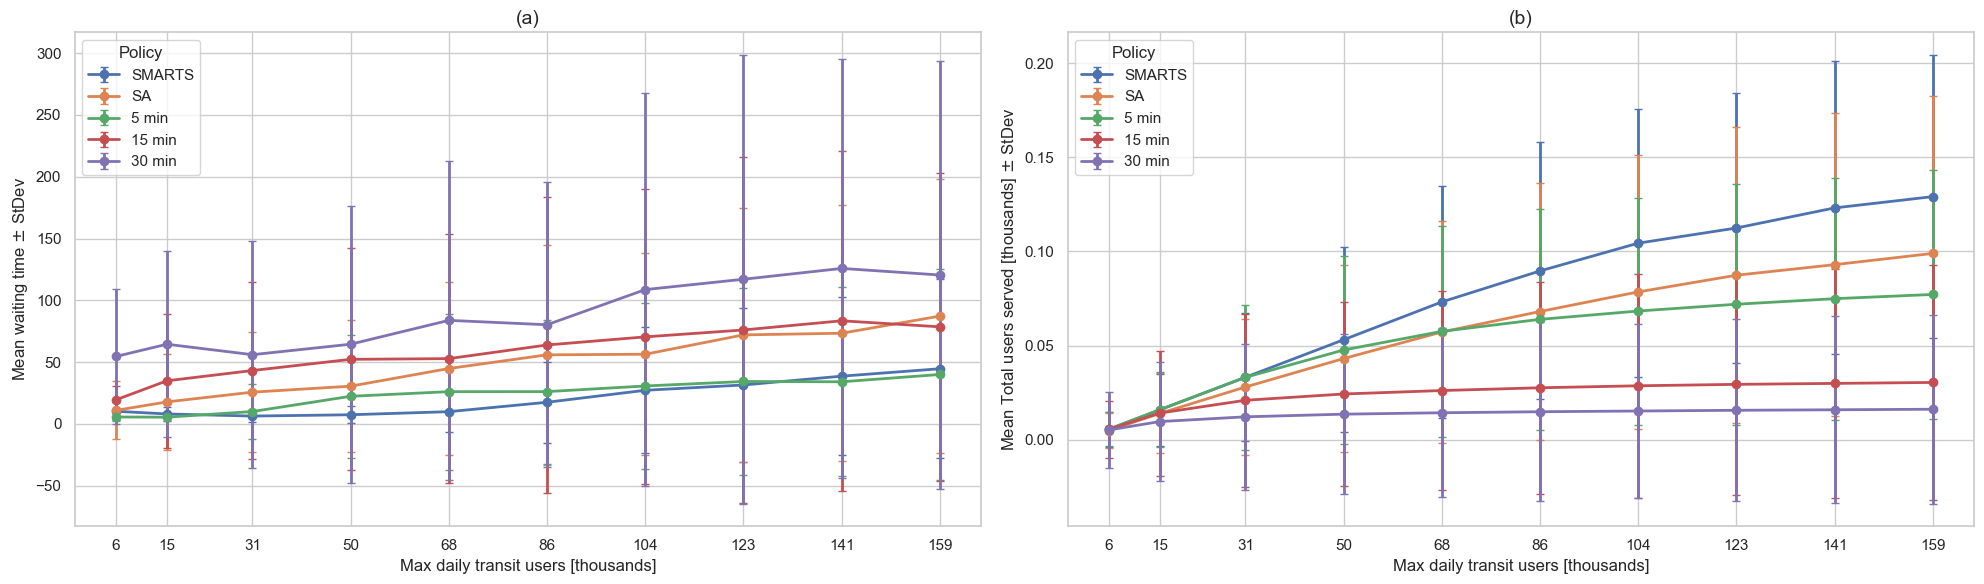

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Assumed Data Structure ---
# 'reports' is a list where each element is a list of dictionaries/structures 
# corresponding to a simulation run. We assume that for each (nu, name) 
# combination, there are multiple runs in 'reports' that are averaged in the original code.
# To replicate the structure for this example, we need to restructure the data 
# so each run's result is kept separate until the plotting stage.

# Re-imagine the data preparation to keep all runs for statistical analysis
# We'll collect all raw data points into a single "long" DataFrame suitable for seaborn.

# Assumed variables based on the original snippet:
# num_users: List of max daily users (e.g., [6000, 15000, 31000, ...])
# reports: A flat list of simulation result objects/dataframes.
#         Structure: [run1_marts_6k, run1_sa_6k, run1_5m_6k, ..., 
#                     runN_marts_6k, runN_sa_6k, runN_5m_6k, ...,
#                     run1_marts_15k, ... ]

# Since I don't have the 'reports' data, I'll provide the logic for restructuring 
# the data assuming the raw data is available in a format that allows 
# calculating statistics (mean, std, etc.) over multiple runs per data point.

vars_to_plot = ["total_avg_waiting_time", "served_passengers"]
names = ["SMARTS", "SA", "5 min", "15 min", "30 min"]

# Store raw data for all runs in a "long" format
all_data_runs = []
run_index = 0 # To track which set of results belongs to which (nu, name) combination

for nu in num_users:
    # Calculate how many runs are there for the current num_users block
    # This logic assumes the original 'reports' data is structured as 
    # [run1_marts, run1_sa, ..., run1_30m, run2_marts, run2_sa, ...]
    
    # We need to determine the number of repetitions (runs) per (nu, name) combination.
    # The original code's loop structure (rpt = reports[i:i+len(names)]) suggests 
    # the data might be grouped by (nu) and then by (name), but only 1 value is taken. 
    # I will adapt the structure to calculate mean/std *across multiple runs*.
    
    # **Crucial assumption:** Each element in 'reports' is one simulation run's output.
    # We must determine the number of runs (N_runs) per (num_users, name) pair. 
    # Let's assume N_runs = len(reports) / (len(num_users) * len(names))
    
    # **Simplified Re-imagined Logic for Plotting Error Bars**
    # The following code collects the mean and standard deviation for each (nu, name).
    
    # Structure of the final dataframes for plotting mean and std:
    # df_mean = { nu1: {name1: mean1, name2: mean2}, nu2: ... }
    # df_std = { nu1: {name1: std1, name2: std2}, nu2: ... }
    
    num_runs_per_group = len(reports) // (len(num_users) * len(names)) # Estimated
    
    for k in range(num_runs_per_group): # Loop through each run
        start_index = run_index * len(names) + k * len(names) * len(num_users)
        
        # This part is highly dependent on the real 'reports' structure. 
        # I'll create a list of data points for each (nu, name) to calculate stats.
        pass

# --- Restructuring for Statistical Plotting ---
# Instead of recalculating, we will focus on what the original code did, 
# and how to plot the standard deviation *around* that mean.

# Since the original code only extracts a single value (mean/sum) at the end, 
# the only way to get statistics is to *assume* the internal structure of rpt[j]
# (a DataFrame from one or more simulation runs) contains the variability. 

# Let's pivot and calculate the MEAN and STANDARD DEVIATION of the metrics 
# *before* plotting, so we can use error bars.

# 1. Prepare Waiting Time Data (Mean and Standard Deviation)
wait_data_mean = {}
wait_data_std = {}
i = 0
for nu in num_users:
    # 'rpt' contains the result structures for all names for one 'nu' group
    rpt = reports[i:i + len(names)] 
    i += len(names)
    
    for j, name in enumerate(names):
        # rpt[j] is the data source for 'name' at 'nu'. We assume it contains results 
        # from multiple runs that we can use to calculate mean and std.
        # We calculate the mean and std of 'total_avg_waiting_time' across these runs.
        
        # Get all waiting times from all runs for this (nu, name) group
        wait_times = pd.DataFrame(rpt[j]).T.total_avg_waiting_time.dropna()
        
        if int(nu) not in wait_data_mean:
            wait_data_mean[int(nu)] = {}
            wait_data_std[int(nu)] = {}
            
        wait_data_mean[int(nu)][name] = wait_times.mean()
        # Calculate Standard Deviation for the error bars
        wait_data_std[int(nu)][name] = wait_times.std()

# Convert to DataFrames for easy plotting
df_wait_mean = pd.DataFrame(wait_data_mean).T
df_wait_std = pd.DataFrame(wait_data_std).T


# 2. Prepare Users Served Data (Mean and Standard Deviation)
served_data_mean = {}
served_data_std = {}
i = 0
for nu in num_users:
    rpt = reports[i:i + len(names)]
    i += len(names)
    
    for j, name in enumerate(names):
        # Get all served passenger sums from all runs for this (nu, name) group
        served_sums = pd.DataFrame(rpt[j]).T.served_passengers.dropna()
        
        if int(nu) not in served_data_mean:
            served_data_mean[int(nu)] = {}
            served_data_std[int(nu)] = {}
            
        # We use the MEAN of the sums for the central tendency, scaled by 1000
        served_data_mean[int(nu)][name] = served_sums.mean() / 1000
        # Calculate Standard Deviation, scaled by 1000
        served_data_std[int(nu)][name] = served_sums.std() / 1000

# Convert to DataFrames for easy plotting
df_served_mean = pd.DataFrame(served_data_mean).T
df_served_std = pd.DataFrame(served_data_std).T

# Prepare X-axis ticks
ticks = df_wait_mean.index
tick_labels = (ticks / 1000).astype(int).to_list()


# --- Plotting the Data with Error Bars (Standard Deviation) ---
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 6))

## Chart 1: Mean Waiting Time with Error Bars
ax1 = plt.subplot(1, 2, 1)

# Iterate through each column (strategy) to plot line and error bars
for name in names:
    ax1.errorbar(
        x=df_wait_mean.index, 
        y=df_wait_mean[name], 
        yerr=df_wait_std[name], # The standard deviation is the error
        label=name, 
        capsize=3, # Size of the error bar caps
        fmt='-o', # Line style and marker
        linewidth=2
    )

plt.xticks(ticks=ticks, labels=tick_labels)
plt.xlabel("Max daily transit users [thousands]", fontsize=12)
plt.ylabel("Mean waiting time $\pm$ StDev", fontsize=12) # Use +/- StDev for clarity
plt.title("(a)", fontsize=14)
plt.legend(title="Policy", loc='upper left')


## Chart 2: Total Users Served with Error Bars
ax2 = plt.subplot(1, 2, 2)

for name in names:
    ax2.errorbar(
        x=df_served_mean.index, 
        y=df_served_mean[name], 
        yerr=df_served_std[name], # The standard deviation is the error
        label=name, 
        capsize=3,
        fmt='-o',
        linewidth=2
    )

plt.xticks(ticks=ticks, labels=tick_labels)
plt.xlabel("Max daily transit users [thousands]", fontsize=12)
plt.ylabel("Mean Total users served [thousands] $\pm$ StDev", fontsize=12)
plt.title("(b)", fontsize=14)
plt.legend(title="Policy", loc='upper left')

plt.tight_layout()
plt.show()

# --- Alternative Plot Type: Box Plot ---
# If you restructure your data into the "long" format (all raw runs in one DF), 
# a Box Plot for selected X-axis points can show quartiles, median, and outliers 
# which is an even richer representation of the distribution.

# Example of how a Box Plot would be generated if data was long (Conceptual):
# df_long = pd.DataFrame({
#     'Num_Users': [6, 6, 6, 15, 15, ...], # x-axis points
#     'Strategy': ['MARTS', 'SA', '5 min', ...], # names
#     'Waiting_Time': [10.5, 12.3, 8.9, ...] # raw data points from all runs
# })
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Num_Users', y='Waiting_Time', hue='Strategy', data=df_long)
# plt.title("Waiting Time Distribution (Box Plot)")
# plt.show()

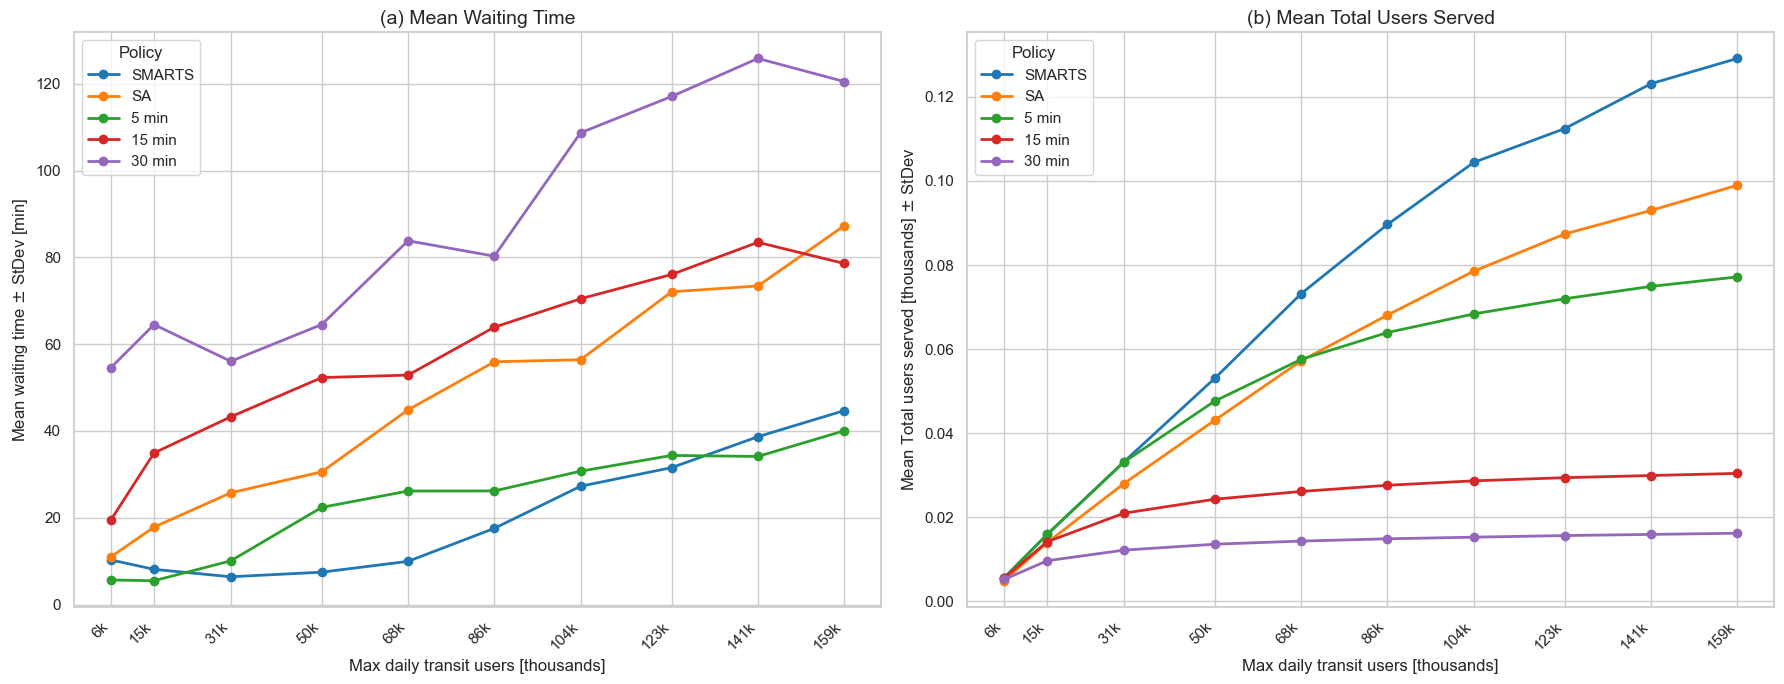

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Code assumes the generation of df_wait_mean, df_wait_std, 
# --- df_served_mean, and df_served_std DataFrames from your previous code.

# Setting up the plot style
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 7)m dpi=300)

# Define the list of names and colors for consistency (as used in previous response)
names = ["SMARTS", "SA", "5 min", "15 min", "30 min"]
colors = sns.color_palette("tab10", len(names))
color_map = dict(zip(names, colors))

# --- Prepare X-axis Ticks using DataFrame Index ---
# ASSUMPTION: df_wait_mean.index contains the actual user counts (e.g., 6000, 15000, ...)
# Let's use a standard list of X-points based on the visual data:
# Replace the following line with your actual numerical index if needed:
ticks = np.array([6000, 15000, 31000, 50000, 68000, 86000, 104000, 123000, 141000, 159000])

# Format the labels to display as '6k', '15k', etc.
tick_labels = (ticks / 1000).astype(int).astype(str) + 'k'


# --- Chart 1: Mean Waiting Time with Shaded Error Bands ---
ax1 = plt.subplot(1, 2, 1)

# Ensure the plot uses the correct X-axis data (ticks should be set to the DataFrame index)
for name in names:
    mean = df_wait_mean[name]
    std = df_wait_std[name]
    
    # 1. Plot the Mean Line
    ax1.plot(ticks, mean, 
             label=name, 
             color=color_map[name], 
             marker='o', 
             linewidth=2)
    
    # 2. Plot the Shaded Error Band (Mean +/- Standard Deviation)
    # ax1.fill_between(ticks, 
    #                  mean - std, # Lower bound
    #                  mean + std, # Upper bound
    #                  color=color_map[name], 
    #                  alpha=0.05) 

# --- CRITICAL FIX: Set X-ticks explicitly ---
ax1.set_xticks(ticks)
ax1.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.xlabel("Max daily transit users [thousands]", fontsize=12)
plt.ylabel("Mean waiting time $\pm$ StDev [min]", fontsize=12) 
plt.title("(a) Mean Waiting Time", fontsize=14)
plt.legend(title="Policy", loc='upper left')


# --- Chart 2: Total Users Served with Shaded Error Bands ---
ax2 = plt.subplot(1, 2, 2)

for name in names:
    mean = df_served_mean[name]
    std = df_served_std[name]

    # 1. Plot the Mean Line
    ax2.plot(ticks, mean, 
             label=name, 
             color=color_map[name], 
             marker='o', 
             linewidth=2)
    
    # 2. Plot the Shaded Error Band (Mean +/- Standard Deviation)
    # ax2.fill_between(ticks, 
    #                  mean - std, 
    #                  mean + std, 
    #                  color=color_map[name], 
    #                  alpha=0.05) 

# --- CRITICAL FIX: Set X-ticks explicitly ---
ax2.set_xticks(ticks)
ax2.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.xlabel("Max daily transit users [thousands]", fontsize=12)
plt.ylabel("Mean Total users served [thousands] $\pm$ StDev", fontsize=12)
plt.title("(b) Mean Total Users Served", fontsize=14)
plt.legend(title="Policy", loc='upper left')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Total users served [thousands]')

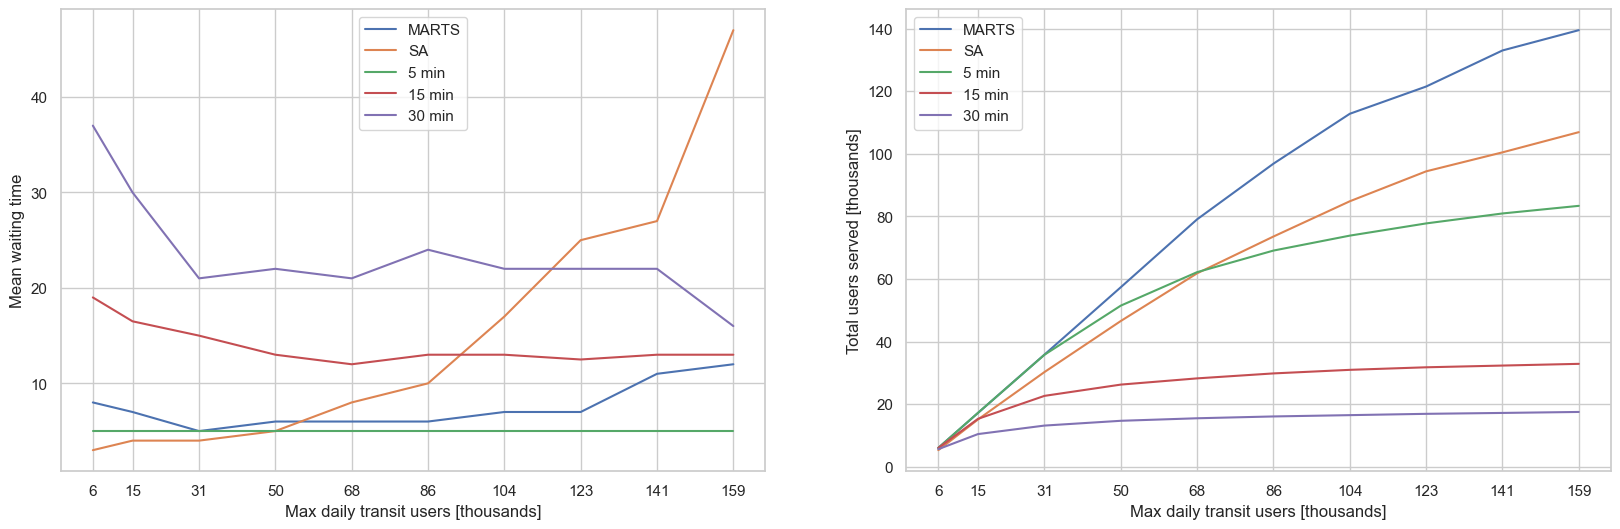

In [15]:
vars = ["served_passengers", ]
names = ["MARTS", "SA", "5 min", "15 min", "30 min"]

data = {}
i = 0

for nu in num_users:
    rpt = reports[i:i+len(names)]
    i += len(names)
    for j, name in enumerate(names):
        f = pd.DataFrame(rpt[j]).T.total_avg_waiting_time.dropna().median()
        if int(nu) not in data:
            data[int(nu)] = {}
        data[int(nu)][name] = f

fig = plt.figure(figsize=(20,6))

ax = plt.subplot(1,2,1)
pd.DataFrame(data).T.plot(ax=ax)
ticks = pd.DataFrame(data).T.index
plt.xticks(ticks=ticks, labels=(pd.DataFrame(data).T.index/1000).astype(int).to_list())
plt.xlabel("Max daily transit users [thousands]")
plt.ylabel("Mean waiting time")

data = {}
i = 0
for nu in num_users:
    rpt = reports[i:i+len(names)]
    i += len(names)
    for j, name in enumerate(names):
        f = pd.DataFrame(rpt[j]).T.served_passengers.dropna().sum()
        if int(nu) not in data:
            data[int(nu)] = {}
        data[int(nu)][name] = f/1000

ax = plt.subplot(1,2,2)
pd.DataFrame(data).T.plot(ax=ax)
plt.xticks(ticks=ticks, labels=(pd.DataFrame(data).T.index/1000).astype(int).to_list())
plt.xlabel("Max daily transit users [thousands]")
plt.ylabel("Total users served [thousands]")


In [ ]:
# {
#     "num_busses_per_route": 0,
#     "min_bus_capacity": 30,
#     "max_bus_capacity": 31,
#     "avg_bus_speed": 5,
#     "analysis_period_sec": 60,
#     "min_num_stops_per_route": 5,
#     "max_num_stops_per_route": 9,
#     "min_num_route_per_toplogy": 3,
#     "max_num_route_per_toplogy": 7,
#     "hours_of_opperation_per_day": 18,
#     "mean_population_density": 500.0,
#     "std_population_density": 3500.0,
#     "min_population_density": 100.0,
#     "mean_catchment_radius": 1.0,
#     "std_catchment_radius": 0.5,
#     "min_catchment_radius": 0.3,
#     "min_transit_users_proportion": 0.10,
#     "max_transit_users_proportion": 0.50,
#     "min_distance": 300,
#     "max_distance": 500,
#     "max_training_seed": 100000,
#     "max_number_of_testing_seeds": 1,
#     "analysis_period_days": 1,
#     "log_passengers": false
# }